<a href="https://colab.research.google.com/github/chamoflag/spatial-failure-node-detection/blob/main/DDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Dual Divergence Framework (DDF) — Clean Research Notebook
==========================================================
Authors: Sanskar Khaire
Version: 1.0.0

Core claim: Deliberately overfit (OFD) and underfit (UFD) ensembles
produce complementary divergence maps. Their combination reliably
identifies failure nodes (MAX_UNC > STABLE) across diverse datasets
and correctly returns null results on structureless data.

Stress test battery:
  Synthetic: Pure Noise, Weak Signal, Hidden Threshold,
             Hidden Interactions, Latent Clusters,
             Heteroscedastic Noise, Covariate Shift,
             Non-stationary Signal
  Real UCI:  Auto MPG, Concrete Strength, Energy Efficiency,
             Wine Quality, Airfoil Noise, Abalone Age,
             California Housing
"""

# ─────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures
)
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from libpysal.weights import KNN as KNN_weights
from esda.moran import Moran

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# ─────────────────────────────────────────────
# 1. SYNTHETIC DATASET GENERATORS
# ─────────────────────────────────────────────
# Eight regimes spanning the full difficulty spectrum.
# Each has a documented expected verdict (NULL or SIGNAL).

def gen_pure_noise(n=500, p=8, seed=42):
    """
    EXPECTED: NULL
    No X-Y relationship whatsoever.
    Gold standard null test — if DDF fires here the method is broken.
    """
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = rng.standard_normal(n)
    return X, y, "Pure Noise", "NULL"


def gen_weak_linear(n=500, p=8, seed=42):
    """
    EXPECTED: NULL or BORDERLINE
    SNR ≈ 0.06. Signal barely above noise floor.
    Tests sensitivity floor — should not fire confidently.
    """
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    signal = 0.3 * X[:, 0] - 0.2 * X[:, 2]
    y = signal + rng.standard_normal(n) * 5.0
    return X, y, "Weak Linear Signal (SNR=0.06)", "NULL"


def gen_hidden_threshold(n=600, p=8, seed=42):
    """
    EXPECTED: SIGNAL
    Sharp boundary at X1=0 AND X3=0.
    No visible geometry in marginals — only detectable via joint structure.
    """
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = np.where(
        (X[:, 0] > 0) & (X[:, 2] > 0),
        2.0 * X[:, 0] + X[:, 2] + rng.standard_normal(n) * 0.5,
        np.where(
            (X[:, 0] <= 0) & (X[:, 2] <= 0),
            -X[:, 0] - 2.0 * X[:, 2] + rng.standard_normal(n) * 0.5,
            rng.standard_normal(n) * 0.3
        )
    )
    return X, y, "Hidden Threshold (X1=0, X3=0)", "SIGNAL"


def gen_hidden_interactions(n=600, p=10, seed=42):
    """
    EXPECTED: SIGNAL
    Y depends only on X1*X2, X3*X4, X5^2.
    Individual features look uncorrelated with Y.
    """
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = (
        2.0 * X[:, 0] * X[:, 1]
        + 1.5 * X[:, 2] * X[:, 3]
        + X[:, 4] ** 2
        + rng.standard_normal(n) * 0.5
    )
    return X, y, "Hidden Interactions (X1*X2, X3*X4, X5²)", "SIGNAL"


def gen_latent_clusters(n=600, p=10, seed=42):
    """
    EXPECTED: SIGNAL
    3 latent clusters with completely different Y-generating processes.
    No cluster labels. Boundary zones are genuine failure nodes.
    """
    rng = np.random.default_rng(seed)
    parts = []
    configs = [
        ([2, 0, -1, 0, 1, 0, 0, 0, 0, 0],
         lambda X: 3*X[:, 0] - X[:, 2]),
        ([-2, 0, 1, 0, -1, 0, 0, 0, 0, 0],
         lambda X: -2*X[:, 0] + X[:, 2]),
        ([0, 2, 0, -1, 0, 1, 0, 0, 0, 0],
         lambda X: X[:, 1]**2 - X[:, 3]**2),
    ]
    for mu, fn in configs:
        Xi = rng.standard_normal((n // 3, p)) + np.array(mu)
        yi = fn(Xi) + rng.standard_normal(n // 3) * 0.3
        parts.append((Xi, yi))

    X = np.vstack([x for x, _ in parts])
    y = np.concatenate([yi for _, yi in parts])
    idx = rng.permutation(len(X))
    return X[idx], y[idx], "Latent Clusters (3 hidden regimes)", "SIGNAL"


def gen_heteroscedastic(n=600, p=6, seed=42):
    """
    EXPECTED: SIGNAL
    Variance of noise increases with X1.
    High-X1 region is the failure zone — models disagree there
    because the data is genuinely noisier, not because of structure.
    Tests whether DDF distinguishes structural complexity from noise variance.
    This is a partial adversarial test.
    """
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    noise_scale = 0.2 + 2.0 * np.abs(X[:, 0])
    y = 2.0 * X[:, 0] + X[:, 1] + rng.standard_normal(n) * noise_scale
    return X, y, "Heteroscedastic Noise (variance ∝ |X1|)", "SIGNAL"


def gen_covariate_shift(n=600, p=6, seed=42):
    """
    EXPECTED: SIGNAL
    Train and test come from different X distributions.
    Test set has X shifted by +3 in first two dimensions.
    Models trained on unshifted data will fail on shifted test points.
    Failure nodes should cluster in the shifted region.
    """
    rng = np.random.default_rng(seed)
    X_tr = rng.standard_normal((n, p))
    X_te_base = rng.standard_normal((n, p))
    # Shift test distribution in first two dims
    X_te_base[:, 0] += 3.0
    X_te_base[:, 1] += 3.0
    X = np.vstack([X_tr, X_te_base])
    y = 2.0 * X[:, 0] - X[:, 1] + rng.standard_normal(2*n) * 0.3
    return X, y, "Covariate Shift (test shifted +3 dims 0,1)", "SIGNAL"


def gen_non_stationary(n=700, p=6, seed=42):
    """
    EXPECTED: SIGNAL
    The relationship between X and Y changes at a hidden time index.
    First half: Y = 2*X1 + X2. Second half: Y = -X1 + 3*X3.
    No time index provided. Models that fit the first regime
    will fail on the second regime and vice versa.
    """
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = np.empty(n)
    half = n // 2
    y[:half] = 2.0*X[:half, 0] + X[:half, 1] + rng.standard_normal(half)*0.3
    y[half:] = -X[half:, 0] + 3.0*X[half:, 2] + rng.standard_normal(n-half)*0.3
    idx = rng.permutation(n)
    return X[idx], y[idx], "Non-stationary Signal (regime change)", "SIGNAL"


# ─────────────────────────────────────────────
# 2. REAL DATASET LOADERS
# ─────────────────────────────────────────────

def load_autoMPG():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/auto-mpg/auto-mpg.data")
    df = pd.read_csv(url, sep=r'\s+', header=None,
        names=['mpg','cylinders','displacement','horsepower',
               'weight','acceleration','model_year','origin','car_name'])
    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
    df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
    df = df.drop(columns=['car_name'])
    return (df.drop(columns=['mpg']).values,
            df['mpg'].values, "Auto MPG", "SIGNAL")

def load_concrete():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/concrete/compressive/Concrete_Data.xls")
    df = pd.read_excel(url)
    return df.iloc[:,:-1].values, df.iloc[:,-1].values, "Concrete Strength", "SIGNAL"

def load_energy():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00242/ENB2012_data.xlsx")
    df = pd.read_excel(url).dropna()
    return df.iloc[:,:-2].values, df.iloc[:,-2].values, "Energy Efficiency", "SIGNAL"

def load_wine():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/wine-quality/winequality-red.csv")
    df = pd.read_csv(url, sep=';')
    return (df.drop(columns=['quality']).values,
            df['quality'].values, "Wine Quality", "SIGNAL")

def load_airfoil():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00291/airfoil_self_noise.dat")
    df = pd.read_csv(url, sep='\t', header=None,
        names=['frequency','angle','chord','velocity','thickness','sound'])
    return df.drop(columns=['sound']).values, df['sound'].values, "Airfoil Noise", "SIGNAL"

def load_abalone():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/abalone/abalone.data")
    df = pd.read_csv(url, header=None,
        names=['sex','length','diameter','height','whole_weight',
               'shucked_weight','viscera_weight','shell_weight','rings'])
    df = pd.get_dummies(df, columns=['sex'], drop_first=True)
    return (df.drop(columns=['rings']).values,
            df['rings'].values, "Abalone Age", "SIGNAL")

def load_california():
    from sklearn.datasets import fetch_california_housing
    data = fetch_california_housing()
    return data.data, data.target, "California Housing", "SIGNAL"


# ─────────────────────────────────────────────
# 3. ENSEMBLE BUILDERS — ALL RIDGE REGULARIZED
# ─────────────────────────────────────────────

def _poly_degree(n):
    """Scale polynomial degree to dataset size to avoid feature explosion."""
    if n < 200:   return 1
    elif n < 500: return 2
    return 3

def _norm01(v):
    rng = v.max() - v.min()
    return (v - v.min()) / (rng + 1e-9)

# --- Overfitting ensemble members ---

def _ofd_poly(X_tr, y_tr, X_te):
    """Ridge polynomial with low alpha (complex, overfit tendency)."""
    d  = _poly_degree(len(X_tr))
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(X_tr))
    Xte_p = poly.transform(sc.transform(X_te))
    preds = [Ridge(alpha=a).fit(Xtr_p, y_tr).predict(Xte_p)
             for a in [0.001, 0.01, 0.1, 1.0, 10.0]]
    return np.array(preds)

def _ofd_tree(X_tr, y_tr, X_te):
    """Deep trees — memorise training partitions."""
    preds = [DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
             .fit(X_tr, y_tr).predict(X_te)
             for d in [1, 2, 4, 8, None]]
    return np.array(preds)

def _ofd_knn(X_tr, y_tr, X_te):
    """Small-k KNN — memorise individual points."""
    sc = MinMaxScaler()
    Xtr, Xte = sc.fit_transform(X_tr), sc.transform(X_te)
    n = len(X_tr)
    ks = sorted(set([max(1, int(n*r)) for r in [0.3, 0.1, 0.05]] + [5, 1]))
    preds = [KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_tr).predict(Xte)
             for k in ks]
    return np.array(preds)

# --- Underfitting ensemble members ---

def _ufd_poly(X_tr, y_tr, X_te):
    """Ridge degree-1 with very high alpha (maximally smooth)."""
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=1, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(X_tr))
    Xte_p = poly.transform(sc.transform(X_te))
    preds = [Ridge(alpha=a).fit(Xtr_p, y_tr).predict(Xte_p)
             for a in [10., 100., 1000., 10000., 100000.]]
    return np.array(preds)

def _ufd_tree(X_tr, y_tr, X_te):
    """Shallow trees only — deliberately too simple."""
    preds = [DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
             .fit(X_tr, y_tr).predict(X_te)
             for d in [1, 2, 3]]
    return np.array(preds)

def _ufd_knn(X_tr, y_tr, X_te):
    """Large-k KNN — over-smooth predictions."""
    sc = MinMaxScaler()
    Xtr, Xte = sc.fit_transform(X_tr), sc.transform(X_te)
    n = len(X_tr)
    ks = sorted(set([max(1, int(n*r)) for r in [0.3, 0.4, 0.5, 0.6, 0.7]]))
    preds = [KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_tr).predict(Xte)
             for k in ks]
    return np.array(preds)


# ─────────────────────────────────────────────
# 4. CROSS-FIT DIVERGENCE + INDEPENDENT RESIDUALS
# ─────────────────────────────────────────────
# Key methodological choice: OFD trains on half-A, UFD trains on half-B.
# Residuals come from a third independent ensemble.
# This breaks self-referential structure in the divergence-error relationship.

def compute_divergence_and_residuals(X_tr, y_tr, X_te, y_te, seed=GLOBAL_SEED):
    """
    Cross-fit OFD and UFD on disjoint halves.
    Residuals from an independent reference ensemble.
    Returns: ofd, ufd, combined (all [0,1]-normalised), residuals
    """
    Xa, Xb, ya, yb = train_test_split(
        X_tr, y_tr, test_size=0.5, random_state=seed
    )

    # OFD on half-A
    ofd_preds = np.vstack([
        _ofd_poly(Xa, ya, X_te),
        _ofd_tree(Xa, ya, X_te),
        _ofd_knn(Xa, ya, X_te),
    ])

    # UFD on half-B
    ufd_preds = np.vstack([
        _ufd_poly(Xb, yb, X_te),
        _ufd_tree(Xb, yb, X_te),
        _ufd_knn(Xb, yb, X_te),
    ])

    ofd_div = ofd_preds.std(axis=0)
    ufd_div = ufd_preds.std(axis=0)

    ofd      = _norm01(ofd_div)
    ufd      = _norm01(ufd_div)
    combined = (ofd + ufd) / 2.0

    # Independent residuals — fresh split, mixed ensemble
    Xc, Xd, yc, yd = train_test_split(
        X_tr, y_tr, test_size=0.5, random_state=seed + 1
    )
    ref_preds = []
    for a in [0.1, 1.0, 10.0]:
        sc = StandardScaler()
        poly = PolynomialFeatures(
            degree=_poly_degree(len(Xc)), include_bias=False)
        Xc_p = poly.fit_transform(sc.fit_transform(Xc))
        Xte_p = poly.transform(sc.transform(X_te))
        ref_preds.append(Ridge(alpha=a).fit(Xc_p, yc).predict(Xte_p))

    sc2 = MinMaxScaler()
    Xd_s = sc2.fit_transform(Xd)
    Xte_s = sc2.transform(X_te)
    n = len(Xd)
    for k in [max(1, int(n*0.2)), max(1, int(n*0.1)), 5]:
        ref_preds.append(
            KNeighborsRegressor(n_neighbors=k).fit(Xd_s, yd).predict(Xte_s)
        )

    mean_pred = np.mean(np.array(ref_preds), axis=0)
    residuals = np.abs(y_te - mean_pred)

    return ofd, ufd, combined, residuals


# ─────────────────────────────────────────────
# 5. SPATIAL STATISTICS
# ─────────────────────────────────────────────

def moran_with_permutation(values, X_scaled, k=None, n_perm=999):
    """
    Moran's I with:
    - Adaptive k (sqrt of n, minimum 5)
    - Permutation p-value (n_perm=999 for publishable precision)
    - Shuffled baseline and its std for delta significance check
    """
    n = len(values)
    if k is None:
        k = max(5, min(int(np.sqrt(n)), n - 1))
    k = min(k, n - 1)

    w = KNN_weights(X_scaled, k=k, silence_warnings=True)
    mo = Moran(values, w, permutations=n_perm)

    # Shuffled baseline
    shuf = values.copy()
    shuffled_I = []
    for _ in range(200):
        np.random.shuffle(shuf)
        shuffled_I.append(Moran(shuf, w).I)

    baseline     = float(np.mean(shuffled_I))
    baseline_std = float(np.std(shuffled_I))
    delta        = float(mo.I) - baseline

    return {
        "I":            float(mo.I),
        "p":            float(mo.p_sim),
        "delta":        delta,
        "baseline":     baseline,
        "baseline_std": baseline_std,
        "k":            k,
        # Delta significant if > 2 std above shuffled baseline
        "delta_sig":    delta > 2.0 * baseline_std,
    }

def multi_scale_moran(values, X_te, k_list=(3, 5, 10, 15, 20, 30)):
    """Moran's I at multiple neighbourhood scales — reveals failure radius."""
    X_std = StandardScaler().fit_transform(X_te)
    rows = []
    for k in k_list:
        if k >= len(X_te):
            continue
        w  = KNN_weights(X_std, k=k, silence_warnings=True)
        mi = Moran(values, w).I
        rows.append({"k": k, "moran_I": mi})
    return pd.DataFrame(rows)


# ─────────────────────────────────────────────
# 6. QUADRANT CLASSIFICATION
# ─────────────────────────────────────────────

QUADRANT_ORDER = ["MAX_UNC", "DATA_SP", "STRUCT_C", "STABLE"]
MIN_QUADRANT_N = 20   # minimum points to trust a quadrant mean

def classify_quadrants(ofd, ufd):
    ot, ut = np.median(ofd), np.median(ufd)
    labels = []
    for o, u in zip(ofd, ufd):
        if   o > ot and u > ut:  labels.append("MAX_UNC")
        elif o > ot and u <= ut: labels.append("DATA_SP")
        elif o <= ot and u > ut: labels.append("STRUCT_C")
        else:                    labels.append("STABLE")
    return np.array(labels)

def quadrant_profile(labels, residuals):
    out = {}
    for q in QUADRANT_ORDER:
        mask = labels == q
        n    = int(mask.sum())
        out[q] = {
            "n":       n,
            "err":     float(residuals[mask].mean()) if n > 0 else np.nan,
            "trusted": n >= MIN_QUADRANT_N,
        }
    return out


# ─────────────────────────────────────────────
# 7. NULL TESTS
# ─────────────────────────────────────────────

def false_positive_test(combined, residuals, n_perm=200):
    """
    Permute divergence labels, recompute high/low ratio each time.
    Tests whether the observed ratio is above the null distribution.
    """
    high = combined > np.percentile(combined, 75)
    low  = combined < np.percentile(combined, 25)
    real_ratio = (residuals[high].mean() /
                  (residuals[low].mean() + 1e-9))

    null_ratios = []
    for _ in range(n_perm):
        perm = np.random.permutation(combined)
        h = perm > np.percentile(perm, 75)
        l = perm < np.percentile(perm, 25)
        null_ratios.append(
            residuals[h].mean() / (residuals[l].mean() + 1e-9)
        )

    null_ratios = np.array(null_ratios)
    p = float((null_ratios >= real_ratio).mean())
    return {
        "real_ratio":   float(real_ratio),
        "null_mean":    float(null_ratios.mean()),
        "null_std":     float(null_ratios.std()),
        "p_value":      p,
        "significant":  p < 0.05,
    }

def contagion_test(combined, residuals, X_te,
                   n_centers=15, nn=8):
    """
    Does divergence in the neighbourhood of a failure center
    predict error in that neighbourhood?
    Positive Spearman = failure propagates spatially.
    """
    X_std = StandardScaler().fit_transform(X_te)
    cidx  = np.where(combined >= np.percentile(combined, 75))[0][:n_centers]

    if len(cidx) == 0:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}

    ndivs, nerrs = [], []
    for ci in cidx:
        dists = np.sqrt(((X_std - X_std[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        nb = np.argsort(dists)[:nn]
        ndivs.extend(combined[nb].tolist())
        nerrs.extend(residuals[nb].tolist())

    if len(ndivs) <= 10:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}

    sp, sp_p = stats.spearmanr(ndivs, nerrs)
    return {
        "spearman":  float(sp),
        "p":         float(sp_p),
        "confirmed": bool(sp > 0.20 and sp_p < 0.05),
    }

def pipeline_permutation_test(X_tr, y_tr, X_te, y_te,
                               real_support, n_perm=30):
    """
    Permute y_tr, rerun full pipeline, compare support count.
    Provides a global p-value for the entire detection procedure.
    30 permutations → smallest achievable p ≈ 0.032.
    """
    null_supports = []
    for _ in range(n_perm):
        y_perm = np.random.permutation(y_tr)
        o, u, c, r = compute_divergence_and_residuals(
            X_tr, y_perm, X_te, y_te
        )
        X_std = StandardScaler().fit_transform(X_te)
        mi    = moran_with_permutation(c, X_std, n_perm=199)
        sp, sp_p = stats.spearmanr(c, r)
        labels = classify_quadrants(o, u)
        qp = quadrant_profile(labels, r)
        ratio_p = (
            qp["MAX_UNC"]["err"] / (qp["STABLE"]["err"] + 1e-9)
            if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
            else np.nan
        )
        fp = false_positive_test(c, r, n_perm=50)
        ct = contagion_test(c, r, X_te)
        _, sc = compute_support(mi, sp, sp_p, ratio_p, fp, ct)
        null_supports.append(sc)

    null_supports = np.array(null_supports)
    p = float((np.sum(null_supports >= real_support) + 1) / (n_perm + 1))
    return p, null_supports


# ─────────────────────────────────────────────
# 8. SUPPORT GATE SYSTEM
# ─────────────────────────────────────────────
# Five independent tests. Each is a binary gate.
# Support count = number of gates passed (0-5).
# Signal declared if support_count >= 4 AND pipeline_p < 0.10.

def compute_support(moran_info, sp_corr, sp_p,
                    ratio, fp, contagion):
    gates = {
        # Gate 1: Moran's I delta is significant
        "moran":    moran_info["delta_sig"] and moran_info["p"] < 0.05,
        # Gate 2: Spearman |r| > 0.20 and significant
        "spearman": abs(sp_corr) > 0.20 and sp_p < 0.05,
        # Gate 3: MU/SZ error ratio > 1.30
        "ratio":    (not np.isnan(ratio)) and ratio > 1.30,
        # Gate 4: False positive test significant
        "fp":       fp["significant"],
        # Gate 5: Contagion confirmed
        "contagion": contagion["confirmed"],
    }
    return gates, int(sum(gates.values()))


# ─────────────────────────────────────────────
# 9. FAILURE RADIUS ANALYSIS
# ─────────────────────────────────────────────

def _exp_decay(d, A, lam, C):
    return A * np.exp(-d / (lam + 1e-9)) + C

def fit_radius(X_te, combined, residuals,
               n_centers=15, nn=20, max_amp_factor=50):
    """
    For each MAX_UNC center: fit exponential decay of divergence
    vs normalised distance. Extract decay constant lambda.
    Amplitude sanity check excludes numerically blown-up fits.
    """
    X_std     = StandardScaler().fit_transform(X_te)
    threshold = np.percentile(combined, 75)
    cidx      = np.where(combined >= threshold)[0]
    rng       = np.random.default_rng(GLOBAL_SEED)
    if len(cidx) > n_centers:
        cidx = rng.choice(cidx, n_centers, replace=False)

    nn = min(nn, len(X_te) - 1)
    records, n_excluded = [], 0
    obs_range = combined.max() - combined.min()
    max_amp   = max_amp_factor * (obs_range + 1e-9)

    for ci in cidx:
        dists = np.sqrt(((X_std - X_std[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        sidx = np.argsort(dists)[:nn]
        sd, sv = dists[sidx], combined[sidx]
        if len(sd) < 5 or sd.max() < 1e-9:
            continue
        nd = sd / sd.max()

        try:
            p0 = [obs_range, max(nd.mean(), 1e-6), sv.min()]
            popt, _ = curve_fit(
                _exp_decay, nd, sv, p0=p0, maxfev=10000,
                bounds=([0, 1e-6, -np.inf], [max_amp, np.inf, np.inf])
            )
            if popt[0] > max_amp:
                n_excluded += 1
                continue
            pred = _exp_decay(nd, *popt)
            tss  = ((sv - sv.mean())**2).sum()
            r2   = 1 - ((sv - pred)**2).sum() / (tss + 1e-9)
            records.append({
                "lambda":    float(popt[1]),
                "amplitude": float(popt[0]),
                "floor":     float(popt[2]),
                "r2":        float(r2),
                "center_err": float(residuals[ci]),
            })
        except Exception:
            n_excluded += 1

    if not records:
        return None, n_excluded

    df = pd.DataFrame(records)
    return {
        "n_centers":     len(df),
        "n_excluded":    n_excluded,
        "median_lambda": float(df["lambda"].median()),
        "mean_lambda":   float(df["lambda"].mean()),
        "std_lambda":    float(df["lambda"].std()),
        "mean_r2":       float(df["r2"].mean()),
    }, n_excluded


# ─────────────────────────────────────────────
# 10. MAIN ANALYSIS RUNNER
# ─────────────────────────────────────────────

def run_analysis(X, y, dname, expected, verbose=True):
    """
    Full DDF pipeline on one dataset.
    Returns a result dict for the summary table.
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=GLOBAL_SEED
    )

    ofd, ufd, combined, residuals = compute_divergence_and_residuals(
        X_tr, y_tr, X_te, y_te
    )

    X_te_std  = StandardScaler().fit_transform(X_te)
    moran_info = moran_with_permutation(combined, X_te_std, n_perm=999)
    sp_corr, sp_p = stats.spearmanr(combined, residuals)

    labels = classify_quadrants(ofd, ufd)
    qp     = quadrant_profile(labels, residuals)

    ratio = (
        qp["MAX_UNC"]["err"] / (qp["STABLE"]["err"] + 1e-9)
        if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
        else np.nan
    )

    fp        = false_positive_test(combined, residuals)
    contagion = contagion_test(combined, residuals, X_te)
    gates, support_count = compute_support(
        moran_info, sp_corr, sp_p, ratio, fp, contagion
    )

    pipe_p, null_dist = pipeline_permutation_test(
        X_tr, y_tr, X_te, y_te, support_count, n_perm=30
    )

    radius_info, n_excl = fit_radius(X_te, combined, residuals)
    ms_df = multi_scale_moran(combined, X_te)

    # Signal decision
    signal = (support_count >= 4) and (pipe_p < 0.10)
    correct = (signal and expected == "SIGNAL") or \
              (not signal and expected == "NULL")

    if verbose:
        _print_result(dname, expected, moran_info, sp_corr, sp_p,
                      ratio, fp, contagion, gates, support_count,
                      pipe_p, null_dist, qp, ms_df, radius_info,
                      n_excl, signal, correct)

    return {
        "dataset":       dname,
        "expected":      expected,
        "n_train":       len(X_tr),
        "n_test":        len(X_te),
        "moran_I":       moran_info["I"],
        "moran_p":       moran_info["p"],
        "moran_delta":   moran_info["delta"],
        "spearman":      sp_corr,
        "spearman_p":    sp_p,
        "ratio":         ratio if not np.isnan(ratio) else 0.0,
        "fp_p":          fp["p_value"],
        "contagion_sp":  contagion["spearman"],
        "support_count": support_count,
        "pipeline_p":    pipe_p,
        "signal":        signal,
        "correct":       correct,
        "med_lambda":    radius_info["median_lambda"] if radius_info else np.nan,
    }


def _print_result(dname, expected, moran_info, sp_corr, sp_p,
                  ratio, fp, contagion, gates, support_count,
                  pipe_p, null_dist, qp, ms_df, radius_info,
                  n_excl, signal, correct):
    print(f"\n{'='*65}")
    print(f"  {dname}")
    print(f"  Expected: {expected}  |  "
          f"{'✓ CORRECT' if correct else '✗ WRONG'}")
    print(f"{'='*65}")

    print(f"\n  Spatial:")
    print(f"    Moran I={moran_info['I']:.4f}  p={moran_info['p']:.4f}  "
          f"delta={moran_info['delta']:.4f}  "
          f"({'sig' if moran_info['delta_sig'] else 'not sig'})")

    print(f"\n  Point-level:")
    print(f"    Spearman={sp_corr:.4f}  p={sp_p:.6f}")
    print(f"    MU/SZ ratio={'N/A' if np.isnan(ratio) else f'{ratio:.4f}x'}")

    print(f"\n  Null tests:")
    print(f"    FP p={fp['p_value']:.4f}  "
          f"({'sig' if fp['significant'] else 'not sig'})")
    print(f"    Contagion sp={contagion['spearman']:.3f}  "
          f"p={contagion['p']:.4f}  "
          f"({'confirmed' if contagion['confirmed'] else 'none'})")

    print(f"\n  Quadrant errors:")
    for q in QUADRANT_ORDER:
        qd = qp[q]
        flag = "" if qd["trusted"] else " *"
        print(f"    {q:<10}: {qd['err']:.4f}  n={qd['n']}{flag}")
    print(f"    (* < {MIN_QUADRANT_N} pts — untrusted)")

    print(f"\n  Multi-scale Moran:")
    for _, row in ms_df.iterrows():
        bar = "█" * max(0, int(row["moran_I"] * 30))
        print(f"    k={int(row['k']):>3}: {row['moran_I']:>6.3f}  {bar}")

    if radius_info:
        print(f"\n  Failure radius ({radius_info['n_centers']} centers, "
              f"{n_excl} excluded):")
        print(f"    Median λ={radius_info['median_lambda']:.4f}  "
              f"Mean λ={radius_info['mean_lambda']:.4f}  "
              f"R²={radius_info['mean_r2']:.3f}")

    print(f"\n  Gates:")
    for g, v in gates.items():
        print(f"    {g:<12}: {'PASS' if v else 'FAIL'}")
    print(f"    Support   : {support_count}/5")
    print(f"    Pipeline p: {pipe_p:.4f}  "
          f"(null mean={null_dist.mean():.2f}±{null_dist.std():.2f})")
    print(f"\n  VERDICT: "
          f"{'SIGNAL DETECTED' if signal else 'NO SIGNAL'}")


# ─────────────────────────────────────────────
# 11. FULL BATTERY RUNNER
# ─────────────────────────────────────────────

def run_full_battery():
    synthetic = [
        gen_pure_noise,
        gen_weak_linear,
        gen_hidden_threshold,
        gen_hidden_interactions,
        gen_latent_clusters,
        gen_heteroscedastic,
        gen_covariate_shift,
        gen_non_stationary,
    ]

    real = [
        load_autoMPG,
        load_concrete,
        load_energy,
        load_wine,
        load_airfoil,
        load_abalone,
        load_california,
    ]

    results = []

    print("\n" + "="*65)
    print("DDF STRESS TEST — SYNTHETIC REGIMES")
    print("="*65)

    for gen_fn in synthetic:
        X, y, dname, expected = gen_fn()
        r = run_analysis(X, y, dname, expected)
        results.append(r)

    print("\n\n" + "="*65)
    print("DDF VALIDATION — REAL UCI DATASETS")
    print("="*65)

    for load_fn in real:
        try:
            X, y, dname, expected = load_fn()
            print(f"\n  Loading {dname}... shape={X.shape}", flush=True)
            r = run_analysis(X, y, dname, expected)
            results.append(r)
        except Exception as e:
            print(f"\n  {dname} — ERROR: {e}")

    return pd.DataFrame(results)


# ─────────────────────────────────────────────
# 12. SUMMARY TABLE + VERDICT
# ─────────────────────────────────────────────

def print_summary(df):
    print(f"\n\n{'='*110}")
    print("DUAL DIVERGENCE FRAMEWORK — FULL RESULTS SUMMARY")
    print(f"{'='*110}")
    print(f"{'Dataset':<40} {'Exp':>6} {'MoranI':>8} {'Delta':>7} "
          f"{'Spear':>7} {'Ratio':>7} {'FP_p':>6} {'Sup':>5} "
          f"{'Pipe_p':>8} {'Lambda':>8}  {'Result':<10} {'Correct'}")
    print("-"*110)

    for _, r in df.iterrows():
        verdict = "SIGNAL" if r["signal"] else "NULL  "
        ok      = "✓" if r["correct"] else "✗"
        lam     = f"{r['med_lambda']:.3f}" if not np.isnan(r["med_lambda"]) else "N/A"
        print(
            f"{r['dataset'][:39]:<40} "
            f"{r['expected']:>6} "
            f"{r['moran_I']:>8.4f} "
            f"{r['moran_delta']:>7.4f} "
            f"{r['spearman']:>7.4f} "
            f"{r['ratio']:>7.3f}x "
            f"{r['fp_p']:>6.3f} "
            f"{r['support_count']:>5} "
            f"{r['pipeline_p']:>8.4f} "
            f"{lam:>8}  "
            f"{verdict:<10} "
            f"{ok}"
        )

    # Accuracy breakdown
    total    = len(df)
    correct  = df["correct"].sum()
    syn_df   = df[df["expected"].isin(["NULL", "SIGNAL"])].copy()
    null_df  = df[df["expected"] == "NULL"]
    sig_df   = df[df["expected"] == "SIGNAL"]

    null_acc = (null_df["correct"].sum() / len(null_df) * 100
                if len(null_df) > 0 else 0)
    sig_acc  = (sig_df["correct"].sum() / len(sig_df) * 100
                if len(sig_df) > 0 else 0)

    print(f"\n{'='*110}")
    print(f"  Overall accuracy : {correct}/{total} "
          f"({correct/total*100:.1f}%)")
    print(f"  NULL accuracy    : {null_df['correct'].sum()}/{len(null_df)} "
          f"({null_acc:.1f}%)")
    print(f"  SIGNAL accuracy  : {sig_df['correct'].sum()}/{len(sig_df)} "
          f"({sig_acc:.1f}%)")

    print(f"\n  PRIMARY CLAIM — MAX_UNC > STABLE:")
    trusted = df[df["ratio"] > 0]
    mu_hold = (trusted["ratio"] > 1.3).sum()
    print(f"  Holds in {mu_hold}/{len(trusted)} datasets with trusted quadrants")

    print(f"\n  FAILURE RADIUS:")
    rad_df = df[~df["med_lambda"].isna()]
    if len(rad_df) > 0:
        print(f"  Median λ range: "
              f"{rad_df['med_lambda'].min():.3f} — "
              f"{rad_df['med_lambda'].max():.3f}")
        print(f"  Mean median λ : {rad_df['med_lambda'].mean():.3f}")

    print(f"\n  BOUNDARY CONDITIONS:")
    print(f"  Datasets where method correctly returns NULL: "
          f"{null_df['correct'].sum()}/{len(null_df)}")
    print(f"  Min dataset size tested: "
          f"{df['n_train'].min() + df['n_test'].min()}")


# ─────────────────────────────────────────────
# 13. EXECUTE
# ─────────────────────────────────────────────

if __name__ == "__main__" or True:
    results_df = run_full_battery()
    print_summary(results_df)


DDF STRESS TEST — SYNTHETIC REGIMES

  Pure Noise
  Expected: NULL  |  ✓ CORRECT

  Spatial:
    Moran I=0.1064  p=0.0010  delta=0.1159  (sig)

  Point-level:
    Spearman=0.0581  p=0.479981
    MU/SZ ratio=1.2729x

  Null tests:
    FP p=0.3800  (not sig)
    Contagion sp=0.065  p=0.4823  (none)

  Quadrant errors:
    MAX_UNC   : 0.9036  n=36
    DATA_SP   : 0.8384  n=39
    STRUCT_C  : 0.8269  n=39
    STABLE    : 0.7099  n=36
    (* < 20 pts — untrusted)

  Multi-scale Moran:
    k=  3:  0.137  ████
    k=  5:  0.160  ████
    k= 10:  0.112  ███
    k= 15:  0.079  ██
    k= 20:  0.065  █
    k= 30:  0.036  █

  Failure radius (15 centers, 0 excluded):
    Median λ=2.1998  Mean λ=54.7977  R²=0.069

  Gates:
    moran       : PASS
    spearman    : FAIL
    ratio       : FAIL
    fp          : FAIL
    contagion   : FAIL
    Support   : 1/5
    Pipeline p: 0.9032  (null mean=1.27±0.93)

  VERDICT: NO SIGNAL

  Weak Linear Signal (SNR=0.06)
  Expected: NULL  |  ✓ CORRECT

  Spatial:


In [ ]:
"""
Dual Divergence Framework (DDF) — Single-Dataset Sensitivity Probe
==================================================================
Target dataset:
  Hidden Interactions (X1*X2, X3*X4, X5²)

Goal:
  Check whether the core divergence signal is already present and
  whether the final decision layer is too conservative.

This version runs ONLY one dataset.
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from libpysal.weights import KNN as KNN_weights
from esda.moran import Moran

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# ─────────────────────────────────────────────
# 1) DATA GENERATOR
# ─────────────────────────────────────────────

def gen_hidden_interactions(n=600, p=10, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = (
        2.0 * X[:, 0] * X[:, 1]
        + 1.5 * X[:, 2] * X[:, 3]
        + X[:, 4] ** 2
        + rng.standard_normal(n) * 0.5
    )
    return X, y, "Hidden Interactions (X1*X2, X3*X4, X5²)", "SIGNAL"

# ─────────────────────────────────────────────
# 2) HELPERS
# ─────────────────────────────────────────────

def _poly_degree(n):
    if n < 200:
        return 1
    elif n < 500:
        return 2
    return 3

def _norm01(v):
    rng = v.max() - v.min()
    return (v - v.min()) / (rng + 1e-9)

# ─────────────────────────────────────────────
# 3) OFD / UFD ENSEMBLES
# ─────────────────────────────────────────────

def _ofd_poly(X_tr, y_tr, X_te):
    d = _poly_degree(len(X_tr))
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(X_tr))
    Xte_p = poly.transform(sc.transform(X_te))
    preds = [
        Ridge(alpha=a).fit(Xtr_p, y_tr).predict(Xte_p)
        for a in [0.001, 0.01, 0.1, 1.0, 10.0]
    ]
    return np.array(preds)

def _ofd_tree(X_tr, y_tr, X_te):
    preds = [
        DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
        .fit(X_tr, y_tr)
        .predict(X_te)
        for d in [1, 2, 4, 8, None]
    ]
    return np.array(preds)

def _ofd_knn(X_tr, y_tr, X_te):
    sc = MinMaxScaler()
    Xtr, Xte = sc.fit_transform(X_tr), sc.transform(X_te)
    n = len(X_tr)
    ks = sorted(set([max(1, int(n * r)) for r in [0.3, 0.1, 0.05]] + [5, 1]))
    preds = [
        KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_tr).predict(Xte)
        for k in ks
    ]
    return np.array(preds)

def _ufd_poly(X_tr, y_tr, X_te):
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=1, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(X_tr))
    Xte_p = poly.transform(sc.transform(X_te))
    preds = [
        Ridge(alpha=a).fit(Xtr_p, y_tr).predict(Xte_p)
        for a in [10.0, 100.0, 1000.0, 10000.0, 100000.0]
    ]
    return np.array(preds)

def _ufd_tree(X_tr, y_tr, X_te):
    preds = [
        DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
        .fit(X_tr, y_tr)
        .predict(X_te)
        for d in [1, 2, 3]
    ]
    return np.array(preds)

def _ufd_knn(X_tr, y_tr, X_te):
    sc = MinMaxScaler()
    Xtr, Xte = sc.fit_transform(X_tr), sc.transform(X_te)
    n = len(X_tr)
    ks = sorted(set([max(1, int(n * r)) for r in [0.3, 0.4, 0.5, 0.6, 0.7]]))
    preds = [
        KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_tr).predict(Xte)
        for k in ks
    ]
    return np.array(preds)

# ─────────────────────────────────────────────
# 4) DIVERGENCE + RESIDUALS
# ─────────────────────────────────────────────

def compute_divergence_and_residuals(X_tr, y_tr, X_te, y_te, seed=GLOBAL_SEED):
    Xa, Xb, ya, yb = train_test_split(X_tr, y_tr, test_size=0.5, random_state=seed)

    ofd_preds = np.vstack([
        _ofd_poly(Xa, ya, X_te),
        _ofd_tree(Xa, ya, X_te),
        _ofd_knn(Xa, ya, X_te),
    ])

    ufd_preds = np.vstack([
        _ufd_poly(Xb, yb, X_te),
        _ufd_tree(Xb, yb, X_te),
        _ufd_knn(Xb, yb, X_te),
    ])

    ofd_div = ofd_preds.std(axis=0)
    ufd_div = ufd_preds.std(axis=0)

    ofd = _norm01(ofd_div)
    ufd = _norm01(ufd_div)
    combined = (ofd + ufd) / 2.0

    # Independent residuals from a separate reference ensemble
    Xc, Xd, yc, yd = train_test_split(X_tr, y_tr, test_size=0.5, random_state=seed + 1)
    ref_preds = []

    for a in [0.1, 1.0, 10.0]:
        sc = StandardScaler()
        poly = PolynomialFeatures(degree=_poly_degree(len(Xc)), include_bias=False)
        Xc_p = poly.fit_transform(sc.fit_transform(Xc))
        Xte_p = poly.transform(sc.transform(X_te))
        ref_preds.append(Ridge(alpha=a).fit(Xc_p, yc).predict(Xte_p))

    sc2 = MinMaxScaler()
    Xd_s = sc2.fit_transform(Xd)
    Xte_s = sc2.transform(X_te)
    n = len(Xd)
    for k in [max(1, int(n * 0.2)), max(1, int(n * 0.1)), 5]:
        ref_preds.append(KNeighborsRegressor(n_neighbors=k).fit(Xd_s, yd).predict(Xte_s))

    mean_pred = np.mean(np.array(ref_preds), axis=0)
    residuals = np.abs(y_te - mean_pred)

    return ofd, ufd, combined, residuals

# ─────────────────────────────────────────────
# 5) SPATIAL STATISTICS
# ─────────────────────────────────────────────

def moran_with_permutation(values, X_scaled, k=None, n_perm=999):
    n = len(values)
    if k is None:
        k = max(5, min(int(np.sqrt(n)), n - 1))
    k = min(k, n - 1)

    w = KNN_weights(X_scaled, k=k, silence_warnings=True)
    mo = Moran(values, w, permutations=n_perm)

    shuf = values.copy()
    shuffled_I = []
    for _ in range(200):
        np.random.shuffle(shuf)
        shuffled_I.append(Moran(shuf, w).I)

    baseline = float(np.mean(shuffled_I))
    baseline_std = float(np.std(shuffled_I))
    delta = float(mo.I) - baseline

    return {
        "I": float(mo.I),
        "p": float(mo.p_sim),
        "delta": delta,
        "baseline": baseline,
        "baseline_std": baseline_std,
        "k": k,
        "delta_sig": delta > 2.0 * baseline_std,
    }

def multi_scale_moran(values, X_te, k_list=(3, 5, 10, 15, 20, 30)):
    X_std = StandardScaler().fit_transform(X_te)
    rows = []
    for k in k_list:
        if k >= len(X_te):
            continue
        w = KNN_weights(X_std, k=k, silence_warnings=True)
        mi = Moran(values, w).I
        rows.append({"k": k, "moran_I": mi})
    return pd.DataFrame(rows)

# ─────────────────────────────────────────────
# 6) QUADRANTS
# ─────────────────────────────────────────────

QUADRANT_ORDER = ["MAX_UNC", "DATA_SP", "STRUCT_C", "STABLE"]
MIN_QUADRANT_N = 20

def classify_quadrants(ofd, ufd):
    ot, ut = np.median(ofd), np.median(ufd)
    labels = []
    for o, u in zip(ofd, ufd):
        if o > ot and u > ut:
            labels.append("MAX_UNC")
        elif o > ot and u <= ut:
            labels.append("DATA_SP")
        elif o <= ot and u > ut:
            labels.append("STRUCT_C")
        else:
            labels.append("STABLE")
    return np.array(labels)

def quadrant_profile(labels, residuals):
    out = {}
    for q in QUADRANT_ORDER:
        mask = labels == q
        n = int(mask.sum())
        out[q] = {
            "n": n,
            "err": float(residuals[mask].mean()) if n > 0 else np.nan,
            "trusted": n >= MIN_QUADRANT_N,
        }
    return out

# ─────────────────────────────────────────────
# 7) NULL / CONTAGION TESTS
# ─────────────────────────────────────────────

def false_positive_test(combined, residuals, n_perm=200):
    high = combined > np.percentile(combined, 75)
    low = combined < np.percentile(combined, 25)
    real_ratio = residuals[high].mean() / (residuals[low].mean() + 1e-9)

    null_ratios = []
    for _ in range(n_perm):
        perm = np.random.permutation(combined)
        h = perm > np.percentile(perm, 75)
        l = perm < np.percentile(perm, 25)
        null_ratios.append(residuals[h].mean() / (residuals[l].mean() + 1e-9))

    null_ratios = np.array(null_ratios)
    p = float((null_ratios >= real_ratio).mean())
    return {
        "real_ratio": float(real_ratio),
        "null_mean": float(null_ratios.mean()),
        "null_std": float(null_ratios.std()),
        "p_value": p,
        "significant": p < 0.05,
    }

def contagion_test(combined, residuals, X_te, n_centers=15, nn=8):
    X_std = StandardScaler().fit_transform(X_te)
    cidx = np.where(combined >= np.percentile(combined, 75))[0][:n_centers]

    if len(cidx) == 0:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}

    ndivs, nerrs = [], []
    for ci in cidx:
        dists = np.sqrt(((X_std - X_std[ci]) ** 2).sum(axis=1))
        dists[ci] = np.inf
        nb = np.argsort(dists)[:nn]
        ndivs.extend(combined[nb].tolist())
        nerrs.extend(residuals[nb].tolist())

    if len(ndivs) <= 10:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}

    sp, sp_p = stats.spearmanr(ndivs, nerrs)
    return {
        "spearman": float(sp),
        "p": float(sp_p),
        "confirmed": bool(sp > 0.20 and sp_p < 0.05),
    }

# ─────────────────────────────────────────────
# 8) GATES + SOFT SCORE
# ─────────────────────────────────────────────

def compute_support(moran_info, sp_corr, sp_p, ratio, fp, contagion):
    gates = {
        "moran": moran_info["delta_sig"] and moran_info["p"] < 0.05,
        "spearman": abs(sp_corr) > 0.20 and sp_p < 0.05,
        "ratio": (not np.isnan(ratio)) and ratio > 1.30,
        "fp": fp["significant"],
        "contagion": contagion["confirmed"],
    }
    return gates, int(sum(gates.values()))

def evidence_score(moran_info, sp_corr, ratio, fp, contagion):
    moran_s = np.clip((moran_info["I"] - 0.05) / 0.25, 0.0, 1.0)
    spear_s = np.clip((abs(sp_corr) - 0.15) / 0.45, 0.0, 1.0) if not np.isnan(sp_corr) else 0.0
    ratio_s = np.clip((ratio - 1.10) / 1.50, 0.0, 1.0) if not np.isnan(ratio) else 0.0
    fp_s = 1.0 if fp["significant"] else 0.0
    cont_sp = contagion.get("spearman", np.nan)
    cont_s = np.clip((cont_sp - 0.10) / 0.40, 0.0, 1.0) if not np.isnan(cont_sp) else 0.0

    return float(0.10 * moran_s + 0.30 * spear_s + 0.20 * ratio_s + 0.15 * fp_s + 0.25 * cont_s)

def get_sensitivity_profile():
    return {
        "support_min": 4,
        "pipe_cutoff": 0.35,      # relaxed only for this one probe
        "evidence_cutoff": 0.58,  # soft fallback
    }

def pipeline_permutation_test(X_tr, y_tr, X_te, y_te, real_support, real_score, n_perm=20):
    null_supports = []
    null_scores = []

    for _ in range(n_perm):
        y_perm = np.random.permutation(y_tr)
        o, u, c, r = compute_divergence_and_residuals(X_tr, y_perm, X_te, y_te)

        X_std = StandardScaler().fit_transform(X_te)
        mi = moran_with_permutation(c, X_std, n_perm=199)
        sp, sp_p = stats.spearmanr(c, r)

        labels = classify_quadrants(o, u)
        qp = quadrant_profile(labels, r)
        ratio = (
            qp["MAX_UNC"]["err"] / (qp["STABLE"]["err"] + 1e-9)
            if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
            else np.nan
        )

        fp = false_positive_test(c, r, n_perm=50)
        ct = contagion_test(c, r, X_te)

        _, sc = compute_support(mi, sp, sp_p, ratio, fp, ct)
        null_supports.append(sc)
        null_scores.append(evidence_score(mi, sp, ratio, fp, ct))

    null_supports = np.array(null_supports)
    null_scores = np.array(null_scores)

    p_support = float((np.sum(null_supports >= real_support) + 1) / (n_perm + 1))
    p_score = float((np.sum(null_scores >= real_score) + 1) / (n_perm + 1))

    return min(p_support, p_score), null_supports, null_scores

# ─────────────────────────────────────────────
# 9) FAILURE RADIUS
# ─────────────────────────────────────────────

def _exp_decay(d, A, lam, C):
    return A * np.exp(-d / (lam + 1e-9)) + C

def fit_radius(X_te, combined, residuals, n_centers=15, nn=20, max_amp_factor=50):
    X_std = StandardScaler().fit_transform(X_te)
    threshold = np.percentile(combined, 75)
    cidx = np.where(combined >= threshold)[0]
    rng = np.random.default_rng(GLOBAL_SEED)

    if len(cidx) > n_centers:
        cidx = rng.choice(cidx, n_centers, replace=False)

    nn = min(nn, len(X_te) - 1)
    records, n_excluded = [], 0
    obs_range = combined.max() - combined.min()
    max_amp = max_amp_factor * (obs_range + 1e-9)

    for ci in cidx:
        dists = np.sqrt(((X_std - X_std[ci]) ** 2).sum(axis=1))
        dists[ci] = np.inf
        sidx = np.argsort(dists)[:nn]
        sd, sv = dists[sidx], combined[sidx]
        if len(sd) < 5 or sd.max() < 1e-9:
            continue
        nd = sd / sd.max()

        try:
            p0 = [obs_range, max(nd.mean(), 1e-6), sv.min()]
            popt, _ = curve_fit(
                _exp_decay, nd, sv, p0=p0, maxfev=10000,
                bounds=([0, 1e-6, -np.inf], [max_amp, np.inf, np.inf])
            )
            if popt[0] > max_amp:
                n_excluded += 1
                continue
            pred = _exp_decay(nd, *popt)
            tss = ((sv - sv.mean()) ** 2).sum()
            r2 = 1 - ((sv - pred) ** 2).sum() / (tss + 1e-9)
            records.append({
                "lambda": float(popt[1]),
                "amplitude": float(popt[0]),
                "floor": float(popt[2]),
                "r2": float(r2),
                "center_err": float(residuals[ci]),
            })
        except Exception:
            n_excluded += 1

    if not records:
        return None, n_excluded

    df = pd.DataFrame(records)
    return {
        "n_centers": len(df),
        "n_excluded": n_excluded,
        "median_lambda": float(df["lambda"].median()),
        "mean_lambda": float(df["lambda"].mean()),
        "std_lambda": float(df["lambda"].std()),
        "mean_r2": float(df["r2"].mean()),
    }, n_excluded

# ─────────────────────────────────────────────
# 10) RUNNER + PRINTING
# ─────────────────────────────────────────────

def _print_result(dname, expected, moran_info, sp_corr, sp_p,
                  ratio, fp, contagion, gates, support_count,
                  pipe_p, null_dist, qp, ms_df, radius_info,
                  n_excl, signal, correct, soft_score):
    print(f"\n{'='*65}")
    print(f"  {dname}")
    print(f"  Expected: {expected}  |  {'✓ CORRECT' if correct else '✗ WRONG'}")
    print(f"{'='*65}")

    print(f"\n  Spatial:")
    print(f"    Moran I={moran_info['I']:.4f}  p={moran_info['p']:.4f}  delta={moran_info['delta']:.4f}  "
          f"({'sig' if moran_info['delta_sig'] else 'not sig'})")

    print(f"\n  Point-level:")
    print(f"    Spearman={sp_corr:.4f}  p={sp_p:.6f}")
    print(f"    MU/SZ ratio={'N/A' if np.isnan(ratio) else f'{ratio:.4f}x'}")
    print(f"    Soft evidence score={soft_score:.4f}")

    print(f"\n  Null tests:")
    print(f"    FP p={fp['p_value']:.4f}  ({'sig' if fp['significant'] else 'not sig'})")
    print(f"    Contagion sp={contagion['spearman']:.3f}  p={contagion['p']:.4f}  "
          f"({'confirmed' if contagion['confirmed'] else 'none'})")

    print(f"\n  Quadrant errors:")
    for q in QUADRANT_ORDER:
        qd = qp[q]
        flag = "" if qd["trusted"] else " *"
        print(f"    {q:<10}: {qd['err']:.4f}  n={qd['n']}{flag}")
    print(f"    (* < {MIN_QUADRANT_N} pts — untrusted)")

    print(f"\n  Multi-scale Moran:")
    for _, row in ms_df.iterrows():
        bar = "█" * max(0, int(row["moran_I"] * 30))
        print(f"    k={int(row['k']):>3}: {row['moran_I']:>6.3f}  {bar}")

    if radius_info:
        print(f"\n  Failure radius ({radius_info['n_centers']} centers, {n_excl} excluded):")
        print(f"    Median λ={radius_info['median_lambda']:.4f}  Mean λ={radius_info['mean_lambda']:.4f}  R²={radius_info['mean_r2']:.3f}")

    print(f"\n  Gates:")
    for g, v in gates.items():
        print(f"    {g:<12}: {'PASS' if v else 'FAIL'}")
    print(f"    Support   : {support_count}/5")
    print(f"    Pipeline p: {pipe_p:.4f}  (null mean={null_dist.mean():.2f}±{null_dist.std():.2f})")
    print(f"\n  VERDICT: {'SIGNAL DETECTED' if signal else 'NO SIGNAL'}")

def run_analysis(X, y, dname, expected, verbose=True):
    profile = get_sensitivity_profile()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=GLOBAL_SEED
    )

    ofd, ufd, combined, residuals = compute_divergence_and_residuals(
        X_tr, y_tr, X_te, y_te
    )

    X_te_std = StandardScaler().fit_transform(X_te)
    moran_info = moran_with_permutation(combined, X_te_std, n_perm=999)
    sp_corr, sp_p = stats.spearmanr(combined, residuals)

    labels = classify_quadrants(ofd, ufd)
    qp = quadrant_profile(labels, residuals)

    ratio = (
        qp["MAX_UNC"]["err"] / (qp["STABLE"]["err"] + 1e-9)
        if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
        else np.nan
    )

    fp = false_positive_test(combined, residuals)
    contagion = contagion_test(combined, residuals, X_te)
    gates, support_count = compute_support(moran_info, sp_corr, sp_p, ratio, fp, contagion)
    soft_score = evidence_score(moran_info, sp_corr, ratio, fp, contagion)

    pipe_p, null_supports, null_scores = pipeline_permutation_test(
        X_tr, y_tr, X_te, y_te, support_count, soft_score, n_perm=20
    )

    radius_info, n_excl = fit_radius(X_te, combined, residuals)
    ms_df = multi_scale_moran(combined, X_te)

    signal = (
        support_count >= profile["support_min"]
        and (pipe_p < profile["pipe_cutoff"] or soft_score >= profile["evidence_cutoff"])
    )

    correct = (signal and expected == "SIGNAL") or (not signal and expected == "NULL")

    if verbose:
        _print_result(
            dname, expected, moran_info, sp_corr, sp_p,
            ratio, fp, contagion, gates, support_count,
            pipe_p, null_scores, qp, ms_df, radius_info,
            n_excl, signal, correct, soft_score
        )

    return {
        "dataset": dname,
        "expected": expected,
        "n_train": len(X_tr),
        "n_test": len(X_te),
        "moran_I": moran_info["I"],
        "moran_p": moran_info["p"],
        "moran_delta": moran_info["delta"],
        "spearman": sp_corr,
        "spearman_p": sp_p,
        "ratio": ratio if not np.isnan(ratio) else 0.0,
        "fp_p": fp["p_value"],
        "contagion_sp": contagion["spearman"],
        "support_count": support_count,
        "soft_score": soft_score,
        "pipeline_p": pipe_p,
        "signal": signal,
        "correct": correct,
        "med_lambda": radius_info["median_lambda"] if radius_info else np.nan,
    }

def print_summary(df):
    print(f"\n\n{'='*100}")
    print("DDF — SINGLE-DATASET SENSITIVITY RESULT")
    print(f"{'='*100}")
    print(f"{'Dataset':<40} {'Exp':>6} {'MoranI':>8} {'Delta':>7} {'Spear':>7} {'Ratio':>7} "
          f"{'Score':>7} {'FP_p':>6} {'Sup':>5} {'Pipe_p':>8} {'Lambda':>8}  {'Result':<10} {'Correct'}")
    print("-"*100)

    for _, r in df.iterrows():
        verdict = "SIGNAL" if r["signal"] else "NULL  "
        ok = "✓" if r["correct"] else "✗"
        lam = f"{r['med_lambda']:.3f}" if not np.isnan(r["med_lambda"]) else "N/A"
        print(
            f"{r['dataset'][:39]:<40} "
            f"{r['expected']:>6} "
            f"{r['moran_I']:>8.4f} "
            f"{r['moran_delta']:>7.4f} "
            f"{r['spearman']:>7.4f} "
            f"{r['ratio']:>7.3f}x "
            f"{r['soft_score']:>7.3f} "
            f"{r['fp_p']:>6.3f} "
            f"{r['support_count']:>5} "
            f"{r['pipeline_p']:>8.4f} "
            f"{lam:>8}  "
            f"{verdict:<10} "
            f"{ok}"
        )

    total = len(df)
    correct = df["correct"].sum()
    print(f"\n{'='*100}")
    print(f"  Overall accuracy : {correct}/{total} ({correct/total*100:.1f}%)")

# ─────────────────────────────────────────────
# 11) EXECUTE ONLY THIS ONE DATASET
# ─────────────────────────────────────────────

if __name__ == "__main__":
    X, y, dname, expected = gen_hidden_interactions()
    result = run_analysis(X, y, dname, expected, verbose=True)
    results_df = pd.DataFrame([result])
    print_summary(results_df)


  Hidden Interactions (X1*X2, X3*X4, X5²)
  Expected: SIGNAL  |  ✓ CORRECT

  Spatial:
    Moran I=0.1021  p=0.0010  delta=0.1056  (sig)

  Point-level:
    Spearman=0.5945  p=0.000000
    MU/SZ ratio=2.4134x
    Soft evidence score=0.8753

  Null tests:
    FP p=0.0000  (sig)
    Contagion sp=0.473  p=0.0000  (confirmed)

  Quadrant errors:
    MAX_UNC   : 1.6580  n=43
    DATA_SP   : 1.4930  n=47
    STRUCT_C  : 0.5354  n=47
    STABLE    : 0.6870  n=43
    (* < 20 pts — untrusted)

  Multi-scale Moran:
    k=  3:  0.175  █████
    k=  5:  0.130  ███
    k= 10:  0.114  ███
    k= 15:  0.100  ███
    k= 20:  0.096  ██
    k= 30:  0.091  ██

  Failure radius (15 centers, 0 excluded):
    Median λ=1.7343  Mean λ=48.7387  R²=0.085

  Gates:
    moran       : PASS
    spearman    : PASS
    ratio       : PASS
    fp          : PASS
    contagion   : PASS
    Support   : 5/5
    Pipeline p: 0.0476  (null mean=0.25±0.13)

  VERDICT: SIGNAL DETECTED


DDF — SINGLE-DATASET SENSITIVITY RESULT

In [ ]:
"""
Dual Divergence Framework (DDF) — Spot Check Battery
=====================================================
3 fresh datasets not in the original 14:
  1. Yacht Hydrodynamics  (n=308,  p=6)  — nonlinear Froude threshold
  2. Servo                (n=167,  p=4)  — discrete regime pockets
  3. Skillcraft1          (n=3395, p=19) — large-n, partially diffuse

All three expected: SIGNAL
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from libpysal.weights import KNN as KNN_weights
from esda.moran import Moran

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# ─────────────────────────────────────────────
# 1. DATASET LOADERS
# ─────────────────────────────────────────────

def load_yacht():
    """
    Yacht Hydrodynamics (n=308, p=6)
    Residuary resistance is near-zero for low Froude numbers,
    then explodes nonlinearly. Spatially concentrated failure
    zone expected near the Froude threshold.
    """
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00243/yacht_hydrodynamics.data")
    df = pd.read_csv(url, sep=r'\s+', header=None,
                     names=['lcb', 'cp', 'ldR', 'bdR', 'lbR', 'froude', 'resist'])
    X = df.drop(columns=['resist']).values.astype(np.float32)
    y = df['resist'].values.astype(np.float32)
    return X, y, "Yacht Hydrodynamics", "SIGNAL"


def load_servo():
    """
    Servo (n=167, p=4 after encoding)
    Motor type + screw type are categorical — creates discrete
    regime pockets where ensemble members will fundamentally
    disagree. Tiny dataset stress-tests DDF at low n.
    """
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/servo/servo.data")
    df = pd.read_csv(url, header=None,
                     names=['motor', 'screw', 'pgain', 'vgain', 'class'])
    df = pd.get_dummies(df, columns=['motor', 'screw'], drop_first=True)
    X = df.drop(columns=['class']).values.astype(np.float32)
    y = df['class'].values.astype(np.float32)
    return X, y, "Servo", "SIGNAL"


def load_skillcraft():
    """
    Skillcraft1 StarCraft (n=3395, p=19)
    APM and cognitive load features — known heteroscedastic
    structure, partially diffuse failure. Tests DDF at large n
    with a harder detection profile.
    """
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00272/SkillCraft1_Dataset.csv")
    df = pd.read_csv(url)
    df = df.replace('?', np.nan).dropna()
    # Target: LeagueIndex (ordinal, treated as regression)
    target = 'LeagueIndex'
    drop_cols = [target, 'GameID']
    X = df.drop(columns=drop_cols, errors='ignore').values.astype(np.float32)
    y = df[target].values.astype(np.float32)
    return X, y, "Skillcraft1 StarCraft", "SIGNAL"


# ─────────────────────────────────────────────
# 2. HELPERS
# ─────────────────────────────────────────────

def _poly_degree(n):
    if n < 200:   return 1
    elif n < 500: return 2
    return 3

def _norm01(v):
    r = v.max() - v.min()
    return (v - v.min()) / (r + 1e-9)


# ─────────────────────────────────────────────
# 3. OFD / UFD ENSEMBLES
# ─────────────────────────────────────────────

def _ofd_poly(X_tr, y_tr, X_te):
    d = _poly_degree(len(X_tr))
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(X_tr))
    Xte_p = poly.transform(sc.transform(X_te))
    return np.array([Ridge(alpha=a).fit(Xtr_p, y_tr).predict(Xte_p)
                     for a in [0.001, 0.01, 0.1, 1.0, 10.0]])

def _ofd_tree(X_tr, y_tr, X_te):
    return np.array([
        DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
        .fit(X_tr, y_tr).predict(X_te)
        for d in [1, 2, 4, 8, None]
    ])

def _ofd_knn(X_tr, y_tr, X_te):
    sc = MinMaxScaler()
    Xtr, Xte = sc.fit_transform(X_tr), sc.transform(X_te)
    n = len(X_tr)
    ks = sorted(set([max(1, int(n*r)) for r in [0.3, 0.1, 0.05]] + [5, 1]))
    return np.array([KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_tr).predict(Xte)
                     for k in ks])

def _ufd_poly(X_tr, y_tr, X_te):
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=1, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(X_tr))
    Xte_p = poly.transform(sc.transform(X_te))
    return np.array([Ridge(alpha=a).fit(Xtr_p, y_tr).predict(Xte_p)
                     for a in [10., 100., 1000., 10000., 100000.]])

def _ufd_tree(X_tr, y_tr, X_te):
    return np.array([
        DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
        .fit(X_tr, y_tr).predict(X_te)
        for d in [1, 2, 3]
    ])

def _ufd_knn(X_tr, y_tr, X_te):
    sc = MinMaxScaler()
    Xtr, Xte = sc.fit_transform(X_tr), sc.transform(X_te)
    n = len(X_tr)
    ks = sorted(set([max(1, int(n*r)) for r in [0.3, 0.4, 0.5, 0.6, 0.7]]))
    return np.array([KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_tr).predict(Xte)
                     for k in ks])


# ─────────────────────────────────────────────
# 4. DIVERGENCE + RESIDUALS
# ─────────────────────────────────────────────

def compute_divergence_and_residuals(X_tr, y_tr, X_te, y_te, seed=GLOBAL_SEED):
    Xa, Xb, ya, yb = train_test_split(X_tr, y_tr, test_size=0.5, random_state=seed)

    ofd_preds = np.vstack([_ofd_poly(Xa, ya, X_te),
                           _ofd_tree(Xa, ya, X_te),
                           _ofd_knn(Xa, ya, X_te)])

    ufd_preds = np.vstack([_ufd_poly(Xb, yb, X_te),
                           _ufd_tree(Xb, yb, X_te),
                           _ufd_knn(Xb, yb, X_te)])

    ofd = _norm01(ofd_preds.std(axis=0))
    ufd = _norm01(ufd_preds.std(axis=0))
    combined = (ofd + ufd) / 2.0

    Xc, Xd, yc, yd = train_test_split(X_tr, y_tr, test_size=0.5, random_state=seed+1)
    ref_preds = []
    for a in [0.1, 1.0, 10.0]:
        sc = StandardScaler()
        poly = PolynomialFeatures(degree=_poly_degree(len(Xc)), include_bias=False)
        Xc_p = poly.fit_transform(sc.fit_transform(Xc))
        Xte_p = poly.transform(sc.transform(X_te))
        ref_preds.append(Ridge(alpha=a).fit(Xc_p, yc).predict(Xte_p))
    sc2 = MinMaxScaler()
    Xd_s, Xte_s = sc2.fit_transform(Xd), sc2.transform(X_te)
    for k in [max(1, int(len(Xd)*0.2)), max(1, int(len(Xd)*0.1)), 5]:
        ref_preds.append(KNeighborsRegressor(n_neighbors=k)
                         .fit(Xd_s, yd).predict(Xte_s))

    mean_pred = np.mean(np.array(ref_preds), axis=0)
    residuals = np.abs(y_te - mean_pred)
    return ofd, ufd, combined, residuals


# ─────────────────────────────────────────────
# 5. SPATIAL STATISTICS
# ─────────────────────────────────────────────

def moran_with_permutation(values, X_scaled, k=None, n_perm=999):
    n = len(values)
    if k is None:
        k = max(5, min(int(np.sqrt(n)), n - 1))
    k = min(k, n - 1)
    w = KNN_weights(X_scaled, k=k, silence_warnings=True)
    mo = Moran(values, w, permutations=n_perm)
    shuf = values.copy()
    shuffled_I = [Moran(np.random.permutation(shuf), w).I for _ in range(200)]
    baseline = float(np.mean(shuffled_I))
    baseline_std = float(np.std(shuffled_I))
    delta = float(mo.I) - baseline
    return {
        "I": float(mo.I), "p": float(mo.p_sim),
        "delta": delta, "baseline": baseline,
        "baseline_std": baseline_std, "k": k,
        "delta_sig": delta > 2.0 * baseline_std,
    }

def multi_scale_moran(values, X_te, k_list=(3, 5, 10, 15, 20, 30)):
    X_std = StandardScaler().fit_transform(X_te)
    rows = []
    for k in k_list:
        if k >= len(X_te):
            continue
        w = KNN_weights(X_std, k=k, silence_warnings=True)
        rows.append({"k": k, "moran_I": Moran(values, w).I})
    return pd.DataFrame(rows)


# ─────────────────────────────────────────────
# 6. QUADRANT CLASSIFICATION
# ─────────────────────────────────────────────

QUADRANT_ORDER = ["MAX_UNC", "DATA_SP", "STRUCT_C", "STABLE"]
MIN_QUADRANT_N = 20

def classify_quadrants(ofd, ufd):
    ot, ut = np.median(ofd), np.median(ufd)
    labels = []
    for o, u in zip(ofd, ufd):
        if   o > ot and u > ut:  labels.append("MAX_UNC")
        elif o > ot and u <= ut: labels.append("DATA_SP")
        elif o <= ot and u > ut: labels.append("STRUCT_C")
        else:                    labels.append("STABLE")
    return np.array(labels)

def quadrant_profile(labels, residuals):
    out = {}
    for q in QUADRANT_ORDER:
        mask = labels == q
        n = int(mask.sum())
        out[q] = {"n": n,
                  "err": float(residuals[mask].mean()) if n > 0 else np.nan,
                  "trusted": n >= MIN_QUADRANT_N}
    return out


# ─────────────────────────────────────────────
# 7. NULL TESTS
# ─────────────────────────────────────────────

def false_positive_test(combined, residuals, n_perm=200):
    high = combined > np.percentile(combined, 75)
    low  = combined < np.percentile(combined, 25)
    real_ratio = residuals[high].mean() / (residuals[low].mean() + 1e-9)
    null_ratios = []
    for _ in range(n_perm):
        perm = np.random.permutation(combined)
        h = perm > np.percentile(perm, 75)
        l = perm < np.percentile(perm, 25)
        null_ratios.append(residuals[h].mean() / (residuals[l].mean() + 1e-9))
    null_ratios = np.array(null_ratios)
    p = float((null_ratios >= real_ratio).mean())
    return {"real_ratio": float(real_ratio), "null_mean": float(null_ratios.mean()),
            "null_std": float(null_ratios.std()), "p_value": p, "significant": p < 0.05}

def contagion_test(combined, residuals, X_te, n_centers=15, nn=8):
    X_std = StandardScaler().fit_transform(X_te)
    cidx = np.where(combined >= np.percentile(combined, 75))[0][:n_centers]
    if len(cidx) == 0:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}
    ndivs, nerrs = [], []
    for ci in cidx:
        dists = np.sqrt(((X_std - X_std[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        nb = np.argsort(dists)[:nn]
        ndivs.extend(combined[nb].tolist())
        nerrs.extend(residuals[nb].tolist())
    if len(ndivs) <= 10:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}
    sp, sp_p = stats.spearmanr(ndivs, nerrs)
    return {"spearman": float(sp), "p": float(sp_p),
            "confirmed": bool(sp > 0.20 and sp_p < 0.05)}

def pipeline_permutation_test(X_tr, y_tr, X_te, y_te, real_support, n_perm=30):
    null_supports = []
    for _ in range(n_perm):
        y_perm = np.random.permutation(y_tr)
        o, u, c, r = compute_divergence_and_residuals(X_tr, y_perm, X_te, y_te)
        X_std = StandardScaler().fit_transform(X_te)
        mi = moran_with_permutation(c, X_std, n_perm=199)
        sp, sp_p = stats.spearmanr(c, r)
        labels = classify_quadrants(o, u)
        qp = quadrant_profile(labels, r)
        ratio = (qp["MAX_UNC"]["err"] / (qp["STABLE"]["err"] + 1e-9)
                 if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
                 else np.nan)
        fp = false_positive_test(c, r, n_perm=50)
        ct = contagion_test(c, r, X_te)
        _, sc = compute_support(mi, sp, sp_p, ratio, fp, ct)
        null_supports.append(sc)
    null_supports = np.array(null_supports)
    p = float((np.sum(null_supports >= real_support) + 1) / (n_perm + 1))
    return p, null_supports


# ─────────────────────────────────────────────
# 8. SUPPORT GATES
# ─────────────────────────────────────────────

def compute_support(moran_info, sp_corr, sp_p, ratio, fp, contagion):
    gates = {
        "moran":     moran_info["delta_sig"] and moran_info["p"] < 0.05,
        "spearman":  abs(sp_corr) > 0.20 and sp_p < 0.05,
        "ratio":     (not np.isnan(ratio)) and ratio > 1.30,
        "fp":        fp["significant"],
        "contagion": contagion["confirmed"],
    }
    return gates, int(sum(gates.values()))


# ─────────────────────────────────────────────
# 9. FAILURE RADIUS
# ─────────────────────────────────────────────

def _exp_decay(d, A, lam, C):
    return A * np.exp(-d / (lam + 1e-9)) + C

def fit_radius(X_te, combined, residuals, n_centers=15, nn=20, max_amp_factor=50):
    X_std = StandardScaler().fit_transform(X_te)
    threshold = np.percentile(combined, 75)
    cidx = np.where(combined >= threshold)[0]
    rng = np.random.default_rng(GLOBAL_SEED)
    if len(cidx) > n_centers:
        cidx = rng.choice(cidx, n_centers, replace=False)
    nn = min(nn, len(X_te) - 1)
    records, n_excluded = [], 0
    obs_range = combined.max() - combined.min()
    max_amp = max_amp_factor * (obs_range + 1e-9)
    for ci in cidx:
        dists = np.sqrt(((X_std - X_std[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        sidx = np.argsort(dists)[:nn]
        sd, sv = dists[sidx], combined[sidx]
        if len(sd) < 5 or sd.max() < 1e-9:
            continue
        nd = sd / sd.max()
        try:
            p0 = [obs_range, max(nd.mean(), 1e-6), sv.min()]
            popt, _ = curve_fit(_exp_decay, nd, sv, p0=p0, maxfev=10000,
                                bounds=([0, 1e-6, -np.inf], [max_amp, np.inf, np.inf]))
            if popt[0] > max_amp:
                n_excluded += 1
                continue
            pred = _exp_decay(nd, *popt)
            tss = ((sv - sv.mean())**2).sum()
            r2 = 1 - ((sv - pred)**2).sum() / (tss + 1e-9)
            records.append({"lambda": float(popt[1]), "amplitude": float(popt[0]),
                            "floor": float(popt[2]), "r2": float(r2),
                            "center_err": float(residuals[ci])})
        except Exception:
            n_excluded += 1
    if not records:
        return None, n_excluded
    df = pd.DataFrame(records)
    return {"n_centers": len(df), "n_excluded": n_excluded,
            "median_lambda": float(df["lambda"].median()),
            "mean_lambda": float(df["lambda"].mean()),
            "std_lambda": float(df["lambda"].std()),
            "mean_r2": float(df["r2"].mean())}, n_excluded


# ─────────────────────────────────────────────
# 10. RUNNER
# ─────────────────────────────────────────────

def run_analysis(X, y, dname, expected, verbose=True):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=GLOBAL_SEED)

    ofd, ufd, combined, residuals = compute_divergence_and_residuals(
        X_tr, y_tr, X_te, y_te)

    X_te_std = StandardScaler().fit_transform(X_te)
    moran_info = moran_with_permutation(combined, X_te_std, n_perm=999)
    sp_corr, sp_p = stats.spearmanr(combined, residuals)

    labels = classify_quadrants(ofd, ufd)
    qp = quadrant_profile(labels, residuals)
    ratio = (qp["MAX_UNC"]["err"] / (qp["STABLE"]["err"] + 1e-9)
             if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
             else np.nan)

    fp = false_positive_test(combined, residuals)
    contagion = contagion_test(combined, residuals, X_te)
    gates, support_count = compute_support(
        moran_info, sp_corr, sp_p, ratio, fp, contagion)

    pipe_p, null_dist = pipeline_permutation_test(
        X_tr, y_tr, X_te, y_te, support_count, n_perm=30)

    radius_info, n_excl = fit_radius(X_te, combined, residuals)
    ms_df = multi_scale_moran(combined, X_te)

    signal = (support_count >= 4) and (pipe_p < 0.10)
    correct = (signal and expected == "SIGNAL") or \
              (not signal and expected == "NULL")

    if verbose:
        print(f"\n{'='*65}")
        print(f"  {dname}  (n_train={len(X_tr)}, p={X_tr.shape[1]})")
        print(f"  Expected: {expected}  |  {'✓ CORRECT' if correct else '✗ WRONG'}")
        print(f"{'='*65}")
        print(f"\n  Spatial:")
        print(f"    Moran I={moran_info['I']:.4f}  p={moran_info['p']:.4f}  "
              f"delta={moran_info['delta']:.4f}  "
              f"({'sig' if moran_info['delta_sig'] else 'not sig'})")
        print(f"\n  Point-level:")
        print(f"    Spearman={sp_corr:.4f}  p={sp_p:.6f}")
        print(f"    MU/SZ ratio={'N/A' if np.isnan(ratio) else f'{ratio:.4f}x'}")
        print(f"\n  Null tests:")
        print(f"    FP p={fp['p_value']:.4f}  "
              f"({'sig' if fp['significant'] else 'not sig'})")
        print(f"    Contagion sp={contagion['spearman']:.3f}  "
              f"p={contagion['p']:.4f}  "
              f"({'confirmed' if contagion['confirmed'] else 'none'})")
        print(f"\n  Quadrant errors:")
        for q in QUADRANT_ORDER:
            qd = qp[q]
            flag = "" if qd["trusted"] else " *"
            print(f"    {q:<10}: {qd['err']:.4f}  n={qd['n']}{flag}")
        print(f"    (* < {MIN_QUADRANT_N} pts — untrusted)")
        print(f"\n  Multi-scale Moran:")
        for _, row in ms_df.iterrows():
            bar = "█" * max(0, int(row["moran_I"] * 30))
            print(f"    k={int(row['k']):>3}: {row['moran_I']:>6.3f}  {bar}")
        if radius_info:
            print(f"\n  Failure radius ({radius_info['n_centers']} centers, "
                  f"{n_excl} excluded):")
            print(f"    Median λ={radius_info['median_lambda']:.4f}  "
                  f"Mean λ={radius_info['mean_lambda']:.4f}  "
                  f"R²={radius_info['mean_r2']:.3f}")
        print(f"\n  Gates:")
        for g, v in gates.items():
            print(f"    {g:<12}: {'PASS' if v else 'FAIL'}")
        print(f"    Support   : {support_count}/5")
        print(f"    Pipeline p: {pipe_p:.4f}  "
              f"(null mean={null_dist.mean():.2f}±{null_dist.std():.2f})")
        print(f"\n  VERDICT: {'SIGNAL DETECTED' if signal else 'NO SIGNAL'}")

    return {"dataset": dname, "expected": expected,
            "n_train": len(X_tr), "n_test": len(X_te),
            "moran_I": moran_info["I"], "moran_p": moran_info["p"],
            "moran_delta": moran_info["delta"],
            "spearman": sp_corr, "spearman_p": sp_p,
            "ratio": ratio if not np.isnan(ratio) else 0.0,
            "fp_p": fp["p_value"], "contagion_sp": contagion["spearman"],
            "support_count": support_count, "pipeline_p": pipe_p,
            "signal": signal, "correct": correct,
            "med_lambda": radius_info["median_lambda"] if radius_info else np.nan}


# ─────────────────────────────────────────────
# 11. SUMMARY
# ─────────────────────────────────────────────

def print_summary(df):
    print(f"\n\n{'='*105}")
    print("DDF SPOT CHECK — RESULTS SUMMARY")
    print(f"{'='*105}")
    print(f"{'Dataset':<30} {'Exp':>6} {'MoranI':>8} {'Delta':>7} "
          f"{'Spear':>7} {'Ratio':>7} {'FP_p':>6} {'Sup':>5} "
          f"{'Pipe_p':>8} {'Lambda':>8}  {'Result':<10} {'Ok'}")
    print("-"*105)
    for _, r in df.iterrows():
        verdict = "SIGNAL" if r["signal"] else "NULL  "
        ok = "✓" if r["correct"] else "✗"
        lam = f"{r['med_lambda']:.3f}" if not np.isnan(r["med_lambda"]) else "N/A"
        print(f"{r['dataset'][:29]:<30} {r['expected']:>6} "
              f"{r['moran_I']:>8.4f} {r['moran_delta']:>7.4f} "
              f"{r['spearman']:>7.4f} {r['ratio']:>7.3f}x "
              f"{r['fp_p']:>6.3f} {r['support_count']:>5} "
              f"{r['pipeline_p']:>8.4f} {lam:>8}  "
              f"{verdict:<10} {ok}")
    total = len(df)
    correct = df["correct"].sum()
    print(f"\n{'='*105}")
    print(f"  Accuracy: {correct}/{total} ({correct/total*100:.1f}%)")
    print(f"  MAX_UNC > STABLE holds in "
          f"{(df['ratio'] > 1.3).sum()}/{(df['ratio'] > 0).sum()} "
          f"datasets with trusted quadrants")


# ─────────────────────────────────────────────
# 12. EXECUTE
# ─────────────────────────────────────────────

if __name__ == "__main__" or True:
    results = []
    for loader in [load_yacht, load_servo, load_skillcraft]:
        try:
            X, y, dname, expected = loader()
            print(f"\nLoading {dname}... shape={X.shape}", flush=True)
            r = run_analysis(X, y, dname, expected)
            results.append(r)
        except Exception as e:
            print(f"\n{dname} — ERROR: {e}")

    if results:
        print_summary(pd.DataFrame(results))


Loading Yacht Hydrodynamics... shape=(308, 6)

  Yacht Hydrodynamics  (n_train=215, p=6)
  Expected: SIGNAL  |  ✓ CORRECT

  Spatial:
    Moran I=0.2435  p=0.0010  delta=0.2555  (sig)

  Point-level:
    Spearman=0.4798  p=0.000001
    MU/SZ ratio=2.2589x

  Null tests:
    FP p=0.0000  (sig)
    Contagion sp=0.563  p=0.0000  (confirmed)

  Quadrant errors:
    MAX_UNC   : 8.5380  n=32
    DATA_SP   : 8.2055  n=14 *
    STRUCT_C  : 3.5487  n=14 *
    STABLE    : 3.7798  n=33
    (* < 20 pts — untrusted)

  Multi-scale Moran:
    k=  3:  0.258  ███████
    k=  5:  0.287  ████████
    k= 10:  0.245  ███████
    k= 15:  0.215  ██████
    k= 20:  0.182  █████
    k= 30:  0.121  ███

  Failure radius (15 centers, 0 excluded):
    Median λ=42.9998  Mean λ=113.0316  R²=0.070

  Gates:
    moran       : PASS
    spearman    : PASS
    ratio       : PASS
    fp          : PASS
    contagion   : PASS
    Support   : 5/5
    Pipeline p: 0.0968  (null mean=2.10±1.27)

  VERDICT: SIGNAL DETECTED



In [ ]:
"""
Dual Divergence Framework (DDF) — Spot Check Battery v2
=========================================================
3 fresh datasets, completely different domain from previous runs:

  1. Naval Propulsion   (n=11934, p=16) — frigate gas turbine simulator
                                          compressor/turbine degradation
                                          creates hard regime boundaries
  2. Kin8nm             (n=8192,  p=8)  — 8-link robot arm forward kinematics
                                          known highly nonlinear, medium noise
  3. Music Origin       (n=1059,  p=68) — acoustic features predict geographic
                                          latitude of music origin
                                          obscure, interaction-heavy, diffuse

All three expected: SIGNAL
Naval and Kin8nm: spatially concentrated failure expected
Music Origin: borderline/diffuse — honest stress test
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from libpysal.weights import KNN as KNN_weights
from esda.moran import Moran

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)


# ─────────────────────────────────────────────
# 1. DATASET LOADERS
# ─────────────────────────────────────────────

def load_naval():
    """
    Naval Propulsion Plants (n=11934, p=16)
    Direct URL download — no ucimlrepo needed.
    """
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00316/UCI%20CBM%20Dataset.zip")
    import urllib.request, zipfile, io
    with urllib.request.urlopen(url) as resp:
        zf = zipfile.ZipFile(io.BytesIO(resp.read()))
        # the data file inside the zip
        with zf.open("UCI CBM Dataset/data.txt") as f:
            df = pd.read_csv(f, sep=r'\s+', header=None)

    X = df.iloc[:, :-2].values.astype(np.float32)
    y = df.iloc[:, -2].values.astype(np.float32)  # first target: kMc
    rng = np.random.default_rng(GLOBAL_SEED)
    idx = rng.choice(len(X), size=3000, replace=False)
    return X[idx], y[idx], "Naval Propulsion (GT kMc)", "SIGNAL"

def load_kin8nm():
    """
    Kin8nm — 8-link robot arm forward kinematics (n=8192, p=8)
    Predict end-effector distance from target given joint angles.
    Known to be highly nonlinear. Joint angle combinations create
    localised singularity zones where all models disagree.
    Loaded from OpenML directly — no install needed beyond sklearn.
    We subsample 3000 rows for runtime parity with naval.
    """
    from sklearn.datasets import fetch_openml
    ds = fetch_openml(data_id=189, as_frame=False, parser='auto')
    X = ds.data.astype(np.float32)
    y = ds.target.astype(np.float32)
    rng = np.random.default_rng(GLOBAL_SEED)
    idx = rng.choice(len(X), size=3000, replace=False)
    return X[idx], y[idx], "Kin8nm Robot Arm", "SIGNAL"


def load_music_origin():
    """
    Geographical Origin of Music (n=1059, p=68)
    68 acoustic features predict the latitude of a song's
    geographic origin. Interaction-heavy, partially diffuse.
    Deliberately chosen as the hard case in this batch —
    analogous to Skillcraft in the previous run.
    """
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00315/default_plus_ledger.csv")
    df = pd.read_csv(url, header=None)
    # last two cols are lat/lon — predict latitude
    X = df.iloc[:, :-2].values.astype(np.float32)
    y = df.iloc[:, -2].values.astype(np.float32)
    return X, y, "Music Geographic Origin", "SIGNAL"


# ─────────────────────────────────────────────
# 2. HELPERS
# ─────────────────────────────────────────────

def _poly_degree(n):
    if n < 200:   return 1
    elif n < 500: return 2
    return 3

def _norm01(v):
    r = v.max() - v.min()
    return (v - v.min()) / (r + 1e-9)


# ─────────────────────────────────────────────
# 3. OFD / UFD ENSEMBLES
# ─────────────────────────────────────────────

def _ofd_poly(X_tr, y_tr, X_te):
    d = _poly_degree(len(X_tr))
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(X_tr))
    Xte_p = poly.transform(sc.transform(X_te))
    return np.array([Ridge(alpha=a).fit(Xtr_p, y_tr).predict(Xte_p)
                     for a in [0.001, 0.01, 0.1, 1.0, 10.0]])

def _ofd_tree(X_tr, y_tr, X_te):
    return np.array([
        DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
        .fit(X_tr, y_tr).predict(X_te)
        for d in [1, 2, 4, 8, None]
    ])

def _ofd_knn(X_tr, y_tr, X_te):
    sc = MinMaxScaler()
    Xtr, Xte = sc.fit_transform(X_tr), sc.transform(X_te)
    n = len(X_tr)
    ks = sorted(set([max(1, int(n*r)) for r in [0.3, 0.1, 0.05]] + [5, 1]))
    return np.array([KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_tr).predict(Xte)
                     for k in ks])

def _ufd_poly(X_tr, y_tr, X_te):
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=1, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(X_tr))
    Xte_p = poly.transform(sc.transform(X_te))
    return np.array([Ridge(alpha=a).fit(Xtr_p, y_tr).predict(Xte_p)
                     for a in [10., 100., 1000., 10000., 100000.]])

def _ufd_tree(X_tr, y_tr, X_te):
    return np.array([
        DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
        .fit(X_tr, y_tr).predict(X_te)
        for d in [1, 2, 3]
    ])

def _ufd_knn(X_tr, y_tr, X_te):
    sc = MinMaxScaler()
    Xtr, Xte = sc.fit_transform(X_tr), sc.transform(X_te)
    n = len(X_tr)
    ks = sorted(set([max(1, int(n*r)) for r in [0.3, 0.4, 0.5, 0.6, 0.7]]))
    return np.array([KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_tr).predict(Xte)
                     for k in ks])


# ─────────────────────────────────────────────
# 4. DIVERGENCE + RESIDUALS
# ─────────────────────────────────────────────

def compute_divergence_and_residuals(X_tr, y_tr, X_te, y_te, seed=GLOBAL_SEED):
    Xa, Xb, ya, yb = train_test_split(X_tr, y_tr, test_size=0.5, random_state=seed)

    ofd_preds = np.vstack([_ofd_poly(Xa, ya, X_te),
                           _ofd_tree(Xa, ya, X_te),
                           _ofd_knn(Xa, ya, X_te)])
    ufd_preds = np.vstack([_ufd_poly(Xb, yb, X_te),
                           _ufd_tree(Xb, yb, X_te),
                           _ufd_knn(Xb, yb, X_te)])

    ofd = _norm01(ofd_preds.std(axis=0))
    ufd = _norm01(ufd_preds.std(axis=0))
    combined = (ofd + ufd) / 2.0

    Xc, Xd, yc, yd = train_test_split(X_tr, y_tr, test_size=0.5, random_state=seed+1)
    ref_preds = []
    for a in [0.1, 1.0, 10.0]:
        sc = StandardScaler()
        poly = PolynomialFeatures(degree=_poly_degree(len(Xc)), include_bias=False)
        Xc_p = poly.fit_transform(sc.fit_transform(Xc))
        Xte_p = poly.transform(sc.transform(X_te))
        ref_preds.append(Ridge(alpha=a).fit(Xc_p, yc).predict(Xte_p))
    sc2 = MinMaxScaler()
    Xd_s, Xte_s = sc2.fit_transform(Xd), sc2.transform(X_te)
    for k in [max(1, int(len(Xd)*0.2)), max(1, int(len(Xd)*0.1)), 5]:
        ref_preds.append(KNeighborsRegressor(n_neighbors=k)
                         .fit(Xd_s, yd).predict(Xte_s))

    mean_pred = np.mean(np.array(ref_preds), axis=0)
    residuals = np.abs(y_te - mean_pred)
    return ofd, ufd, combined, residuals


# ─────────────────────────────────────────────
# 5. SPATIAL STATISTICS
# ─────────────────────────────────────────────

def moran_with_permutation(values, X_scaled, k=None, n_perm=999):
    n = len(values)
    if k is None:
        k = max(5, min(int(np.sqrt(n)), n - 1))
    k = min(k, n - 1)
    w = KNN_weights(X_scaled, k=k, silence_warnings=True)
    mo = Moran(values, w, permutations=n_perm)
    shuf = values.copy()
    shuffled_I = [Moran(np.random.permutation(shuf), w).I for _ in range(200)]
    baseline = float(np.mean(shuffled_I))
    baseline_std = float(np.std(shuffled_I))
    delta = float(mo.I) - baseline
    return {"I": float(mo.I), "p": float(mo.p_sim),
            "delta": delta, "baseline": baseline,
            "baseline_std": baseline_std, "k": k,
            "delta_sig": delta > 2.0 * baseline_std}

def multi_scale_moran(values, X_te, k_list=(3, 5, 10, 15, 20, 30)):
    X_std = StandardScaler().fit_transform(X_te)
    rows = []
    for k in k_list:
        if k >= len(X_te): continue
        w = KNN_weights(X_std, k=k, silence_warnings=True)
        rows.append({"k": k, "moran_I": Moran(values, w).I})
    return pd.DataFrame(rows)


# ─────────────────────────────────────────────
# 6. QUADRANT CLASSIFICATION
# ─────────────────────────────────────────────

QUADRANT_ORDER = ["MAX_UNC", "DATA_SP", "STRUCT_C", "STABLE"]
MIN_QUADRANT_N = 20

def classify_quadrants(ofd, ufd):
    ot, ut = np.median(ofd), np.median(ufd)
    labels = []
    for o, u in zip(ofd, ufd):
        if   o > ot and u > ut:  labels.append("MAX_UNC")
        elif o > ot and u <= ut: labels.append("DATA_SP")
        elif o <= ot and u > ut: labels.append("STRUCT_C")
        else:                    labels.append("STABLE")
    return np.array(labels)

def quadrant_profile(labels, residuals):
    out = {}
    for q in QUADRANT_ORDER:
        mask = labels == q
        n = int(mask.sum())
        out[q] = {"n": n,
                  "err": float(residuals[mask].mean()) if n > 0 else np.nan,
                  "trusted": n >= MIN_QUADRANT_N}
    return out


# ─────────────────────────────────────────────
# 7. NULL TESTS
# ─────────────────────────────────────────────

def false_positive_test(combined, residuals, n_perm=200):
    high = combined > np.percentile(combined, 75)
    low  = combined < np.percentile(combined, 25)
    real_ratio = residuals[high].mean() / (residuals[low].mean() + 1e-9)
    null_ratios = []
    for _ in range(n_perm):
        perm = np.random.permutation(combined)
        h = perm > np.percentile(perm, 75)
        l = perm < np.percentile(perm, 25)
        null_ratios.append(residuals[h].mean() / (residuals[l].mean() + 1e-9))
    null_ratios = np.array(null_ratios)
    p = float((null_ratios >= real_ratio).mean())
    return {"real_ratio": float(real_ratio), "null_mean": float(null_ratios.mean()),
            "null_std": float(null_ratios.std()), "p_value": p,
            "significant": p < 0.05}

def contagion_test(combined, residuals, X_te, n_centers=15, nn=8):
    X_std = StandardScaler().fit_transform(X_te)
    cidx = np.where(combined >= np.percentile(combined, 75))[0][:n_centers]
    if len(cidx) == 0:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}
    ndivs, nerrs = [], []
    for ci in cidx:
        dists = np.sqrt(((X_std - X_std[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        nb = np.argsort(dists)[:nn]
        ndivs.extend(combined[nb].tolist())
        nerrs.extend(residuals[nb].tolist())
    if len(ndivs) <= 10:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}
    sp, sp_p = stats.spearmanr(ndivs, nerrs)
    return {"spearman": float(sp), "p": float(sp_p),
            "confirmed": bool(sp > 0.20 and sp_p < 0.05)}

def pipeline_permutation_test(X_tr, y_tr, X_te, y_te, real_support, n_perm=30):
    null_supports = []
    for _ in range(n_perm):
        y_perm = np.random.permutation(y_tr)
        o, u, c, r = compute_divergence_and_residuals(X_tr, y_perm, X_te, y_te)
        X_std = StandardScaler().fit_transform(X_te)
        mi = moran_with_permutation(c, X_std, n_perm=199)
        sp, sp_p = stats.spearmanr(c, r)
        labels = classify_quadrants(o, u)
        qp = quadrant_profile(labels, r)
        ratio = (qp["MAX_UNC"]["err"] / (qp["STABLE"]["err"] + 1e-9)
                 if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
                 else np.nan)
        fp = false_positive_test(c, r, n_perm=50)
        ct = contagion_test(c, r, X_te)
        _, sc = compute_support(mi, sp, sp_p, ratio, fp, ct)
        null_supports.append(sc)
    null_supports = np.array(null_supports)
    p = float((np.sum(null_supports >= real_support) + 1) / (n_perm + 1))
    return p, null_supports


# ─────────────────────────────────────────────
# 8. SUPPORT GATES
# ─────────────────────────────────────────────

def compute_support(moran_info, sp_corr, sp_p, ratio, fp, contagion):
    gates = {
        "moran":     moran_info["delta_sig"] and moran_info["p"] < 0.05,
        "spearman":  abs(sp_corr) > 0.20 and sp_p < 0.05,
        "ratio":     (not np.isnan(ratio)) and ratio > 1.30,
        "fp":        fp["significant"],
        "contagion": contagion["confirmed"],
    }
    return gates, int(sum(gates.values()))


# ─────────────────────────────────────────────
# 9. FAILURE RADIUS
# ─────────────────────────────────────────────

def _exp_decay(d, A, lam, C):
    return A * np.exp(-d / (lam + 1e-9)) + C

def fit_radius(X_te, combined, residuals, n_centers=15, nn=20, max_amp_factor=50):
    X_std = StandardScaler().fit_transform(X_te)
    threshold = np.percentile(combined, 75)
    cidx = np.where(combined >= threshold)[0]
    rng = np.random.default_rng(GLOBAL_SEED)
    if len(cidx) > n_centers:
        cidx = rng.choice(cidx, n_centers, replace=False)
    nn = min(nn, len(X_te) - 1)
    records, n_excluded = [], 0
    obs_range = combined.max() - combined.min()
    max_amp = max_amp_factor * (obs_range + 1e-9)
    for ci in cidx:
        dists = np.sqrt(((X_std - X_std[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        sidx = np.argsort(dists)[:nn]
        sd, sv = dists[sidx], combined[sidx]
        if len(sd) < 5 or sd.max() < 1e-9: continue
        nd = sd / sd.max()
        try:
            p0 = [obs_range, max(nd.mean(), 1e-6), sv.min()]
            popt, _ = curve_fit(_exp_decay, nd, sv, p0=p0, maxfev=10000,
                                bounds=([0, 1e-6, -np.inf], [max_amp, np.inf, np.inf]))
            if popt[0] > max_amp:
                n_excluded += 1
                continue
            pred = _exp_decay(nd, *popt)
            tss = ((sv - sv.mean())**2).sum()
            r2 = 1 - ((sv - pred)**2).sum() / (tss + 1e-9)
            records.append({"lambda": float(popt[1]), "amplitude": float(popt[0]),
                            "floor": float(popt[2]), "r2": float(r2),
                            "center_err": float(residuals[ci])})
        except Exception:
            n_excluded += 1
    if not records:
        return None, n_excluded
    df = pd.DataFrame(records)
    return {"n_centers": len(df), "n_excluded": n_excluded,
            "median_lambda": float(df["lambda"].median()),
            "mean_lambda": float(df["lambda"].mean()),
            "std_lambda": float(df["lambda"].std()),
            "mean_r2": float(df["r2"].mean())}, n_excluded


# ─────────────────────────────────────────────
# 10. RUNNER
# ─────────────────────────────────────────────

def run_analysis(X, y, dname, expected, verbose=True):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=GLOBAL_SEED)

    ofd, ufd, combined, residuals = compute_divergence_and_residuals(
        X_tr, y_tr, X_te, y_te)

    X_te_std = StandardScaler().fit_transform(X_te)
    moran_info = moran_with_permutation(combined, X_te_std, n_perm=999)
    sp_corr, sp_p = stats.spearmanr(combined, residuals)

    labels = classify_quadrants(ofd, ufd)
    qp = quadrant_profile(labels, residuals)
    ratio = (qp["MAX_UNC"]["err"] / (qp["STABLE"]["err"] + 1e-9)
             if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
             else np.nan)

    fp = false_positive_test(combined, residuals)
    contagion = contagion_test(combined, residuals, X_te)
    gates, support_count = compute_support(
        moran_info, sp_corr, sp_p, ratio, fp, contagion)

    pipe_p, null_dist = pipeline_permutation_test(
        X_tr, y_tr, X_te, y_te, support_count, n_perm=30)

    radius_info, n_excl = fit_radius(X_te, combined, residuals)
    ms_df = multi_scale_moran(combined, X_te)

    signal = (support_count >= 4) and (pipe_p < 0.10)
    correct = (signal and expected == "SIGNAL") or \
              (not signal and expected == "NULL")

    if verbose:
        print(f"\n{'='*65}")
        print(f"  {dname}  (n_train={len(X_tr)}, p={X_tr.shape[1]})")
        print(f"  Expected: {expected}  |  {'✓ CORRECT' if correct else '✗ WRONG'}")
        print(f"{'='*65}")
        print(f"\n  Spatial:")
        print(f"    Moran I={moran_info['I']:.4f}  p={moran_info['p']:.4f}  "
              f"delta={moran_info['delta']:.4f}  "
              f"({'sig' if moran_info['delta_sig'] else 'not sig'})")
        print(f"\n  Point-level:")
        print(f"    Spearman={sp_corr:.4f}  p={sp_p:.6f}")
        print(f"    MU/SZ ratio={'N/A' if np.isnan(ratio) else f'{ratio:.4f}x'}")
        print(f"\n  Null tests:")
        print(f"    FP p={fp['p_value']:.4f}  "
              f"({'sig' if fp['significant'] else 'not sig'})")
        print(f"    Contagion sp={contagion['spearman']:.3f}  "
              f"p={contagion['p']:.4f}  "
              f"({'confirmed' if contagion['confirmed'] else 'none'})")
        print(f"\n  Quadrant errors:")
        for q in QUADRANT_ORDER:
            qd = qp[q]
            flag = "" if qd["trusted"] else " *"
            print(f"    {q:<10}: {qd['err']:.4f}  n={qd['n']}{flag}")
        print(f"    (* < {MIN_QUADRANT_N} pts — untrusted)")
        print(f"\n  Multi-scale Moran:")
        for _, row in ms_df.iterrows():
            bar = "█" * max(0, int(row["moran_I"] * 30))
            print(f"    k={int(row['k']):>3}: {row['moran_I']:>6.3f}  {bar}")
        if radius_info:
            print(f"\n  Failure radius ({radius_info['n_centers']} centers, "
                  f"{n_excl} excluded):")
            print(f"    Median λ={radius_info['median_lambda']:.4f}  "
                  f"Mean λ={radius_info['mean_lambda']:.4f}  "
                  f"R²={radius_info['mean_r2']:.3f}")
        print(f"\n  Gates:")
        for g, v in gates.items():
            print(f"    {g:<12}: {'PASS' if v else 'FAIL'}")
        print(f"    Support   : {support_count}/5")
        print(f"    Pipeline p: {pipe_p:.4f}  "
              f"(null mean={null_dist.mean():.2f}±{null_dist.std():.2f})")
        print(f"\n  VERDICT: {'SIGNAL DETECTED' if signal else 'NO SIGNAL'}")

    return {"dataset": dname, "expected": expected,
            "n_train": len(X_tr), "n_test": len(X_te),
            "moran_I": moran_info["I"], "moran_p": moran_info["p"],
            "moran_delta": moran_info["delta"],
            "spearman": sp_corr, "spearman_p": sp_p,
            "ratio": ratio if not np.isnan(ratio) else 0.0,
            "fp_p": fp["p_value"], "contagion_sp": contagion["spearman"],
            "support_count": support_count, "pipeline_p": pipe_p,
            "signal": signal, "correct": correct,
            "med_lambda": radius_info["median_lambda"] if radius_info else np.nan}


# ─────────────────────────────────────────────
# 11. SUMMARY
# ─────────────────────────────────────────────

def print_summary(df):
    print(f"\n\n{'='*105}")
    print("DDF SPOT CHECK v2 — RESULTS SUMMARY")
    print(f"{'='*105}")
    print(f"{'Dataset':<32} {'Exp':>6} {'MoranI':>8} {'Delta':>7} "
          f"{'Spear':>7} {'Ratio':>7} {'FP_p':>6} {'Sup':>5} "
          f"{'Pipe_p':>8} {'Lambda':>8}  {'Result':<10} {'Ok'}")
    print("-"*105)
    for _, r in df.iterrows():
        verdict = "SIGNAL" if r["signal"] else "NULL  "
        ok = "✓" if r["correct"] else "✗"
        lam = f"{r['med_lambda']:.3f}" if not np.isnan(r["med_lambda"]) else "N/A"
        print(f"{r['dataset'][:31]:<32} {r['expected']:>6} "
              f"{r['moran_I']:>8.4f} {r['moran_delta']:>7.4f} "
              f"{r['spearman']:>7.4f} {r['ratio']:>7.3f}x "
              f"{r['fp_p']:>6.3f} {r['support_count']:>5} "
              f"{r['pipeline_p']:>8.4f} {lam:>8}  "
              f"{verdict:<10} {ok}")
    total = len(df)
    correct = df["correct"].sum()
    print(f"\n{'='*105}")
    print(f"  Accuracy: {correct}/{total} ({correct/total*100:.1f}%)")
    print(f"  MAX_UNC > STABLE holds in "
          f"{(df['ratio'] > 1.3).sum()}/{(df['ratio'] > 0).sum()} "
          f"datasets with trusted quadrants")


# ─────────────────────────────────────────────
# 12. EXECUTE
# ─────────────────────────────────────────────

if __name__ == "__main__" or True:
    results = []
    for loader in [load_naval, load_kin8nm, load_music_origin]:
        try:
            X, y, dname, expected = loader()
            print(f"\nLoading {dname}... shape={X.shape}", flush=True)
            r = run_analysis(X, y, dname, expected)
            results.append(r)
        except Exception as e:
            print(f"\n{dname} — ERROR: {e}")

    if results:
        print_summary(pd.DataFrame(results))


Loading Naval Propulsion (GT kMc)... shape=(3000, 16)

  Naval Propulsion (GT kMc)  (n_train=2100, p=16)
  Expected: SIGNAL  |  ✓ CORRECT

  Spatial:
    Moran I=0.5178  p=0.0010  delta=0.5184  (sig)

  Point-level:
    Spearman=0.5712  p=0.000000
    MU/SZ ratio=2.6516x

  Null tests:
    FP p=0.0000  (sig)
    Contagion sp=0.439  p=0.0000  (confirmed)

  Quadrant errors:
    MAX_UNC   : 0.0079  n=222
    DATA_SP   : 0.0083  n=228
    STRUCT_C  : 0.0024  n=228
    STABLE    : 0.0030  n=222
    (* < 20 pts — untrusted)

  Multi-scale Moran:
    k=  3:  0.847  █████████████████████████
    k=  5:  0.809  ████████████████████████
    k= 10:  0.735  ██████████████████████
    k= 15:  0.665  ███████████████████
    k= 20:  0.607  ██████████████████
    k= 30:  0.518  ███████████████

  Failure radius (15 centers, 0 excluded):
    Median λ=84.3386  Mean λ=125.1093  R²=0.219

  Gates:
    moran       : PASS
    spearman    : PASS
    ratio       : PASS
    fp          : PASS
    contagion  

In [ ]:
"""
═══════════════════════════════════════════════════════════════════
 DUAL DIVERGENCE FRAMEWORK (DDF) — Full Research Battery v2.0
═══════════════════════════════════════════════════════════════════
 Author : Sanskar Khaire  |  github.com/chamoflag/DDF
 Version: 2.0  (paper-ready, single-cell execution)

 Changes from v1.0
 ─────────────────
 1. Polynomial degree formula unified:
       degree = 1 if n_train < 200
               2 if 200 ≤ n_train < 500
               3 otherwise          (max 3, always)
    Appendix A, code, and paper description now agree.

 2. Pipeline permutation null corrected:
    Old: permute y_train (keeps X geometry → inflated null)
    New: replace X_te with iid N(0,1) of same shape
         This destroys ALL spatial structure → tight null
         (mean support ≈ 0.25 vs real structured ≥ 4)

 3. Figures auto-generated at the end (matplotlib):
    Fig 1 — 2×2 Quadrant Taxonomy diagram
    Fig 2 — Error hierarchy bar chart (all datasets)
    Fig 3 — Multi-scale Moran decay curves

 4. Single unified dataset list — 19 datasets, no duplicates.
    Music Geographic Origin removed (inconsistent URL across runs).
    Replaced with Servo + Naval Propulsion + Kin8nm.

 Datasets
 ────────
 Synthetic  (8): Pure Noise, Weak Linear, Hidden Threshold,
                 Hidden Interactions, Latent Clusters,
                 Heteroscedastic, Covariate Shift, Non-stationary
 Real       (11): Auto MPG, Concrete Strength, Energy Efficiency,
                  Wine Quality, Airfoil Noise, Abalone Age,
                  California Housing, Yacht Hydro, Servo,
                  Naval Propulsion, Kin8nm
═══════════════════════════════════════════════════════════════════
"""

# ── 0. IMPORTS ────────────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures
)
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from libpysal.weights import KNN as KNN_weights
from esda.moran import Moran
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import urllib.request, zipfile, io

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# ── 1. POLYNOMIAL DEGREE (unified formula) ───────────────────────

def _poly_degree(n_train: int) -> int:
    """
    Unified rule used in code, paper, and Appendix A:
      n_train < 200  → degree 1
      200 ≤ n < 500  → degree 2
      n ≥ 500        → degree 3   (hard max)
    """
    if n_train < 200:
        return 1
    elif n_train < 500:
        return 2
    return 3

def _norm01(v):
    rng = v.max() - v.min()
    return (v - v.min()) / (rng + 1e-9)

# ── 2. SYNTHETIC DATASET GENERATORS ──────────────────────────────

def gen_pure_noise(n=500, p=8, seed=42):
    """NULL — no X-Y relationship."""
    rng = np.random.default_rng(seed)
    return rng.standard_normal((n, p)), rng.standard_normal(n), \
           "Pure Noise", "NULL"

def gen_weak_linear(n=500, p=8, seed=42):
    """NULL — SNR ≈ 0.06, barely above noise floor."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = 0.3*X[:,0] - 0.2*X[:,2] + rng.standard_normal(n)*5.0
    return X, y, "Weak Linear (SNR=0.06)", "NULL"

def gen_hidden_threshold(n=600, p=8, seed=42):
    """SIGNAL — sharp boundary at X1=0 AND X3=0."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = np.where(
        (X[:,0]>0)&(X[:,2]>0),
        2.0*X[:,0]+X[:,2]+rng.standard_normal(n)*0.5,
        np.where(
            (X[:,0]<=0)&(X[:,2]<=0),
            -X[:,0]-2.0*X[:,2]+rng.standard_normal(n)*0.5,
            rng.standard_normal(n)*0.3
        )
    )
    return X, y, "Hidden Threshold (X1=0,X3=0)", "SIGNAL"

def gen_hidden_interactions(n=600, p=10, seed=42):
    """SIGNAL — Y = f(X1*X2, X3*X4, X5²), invisible in marginals."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = (2.0*X[:,0]*X[:,1] + 1.5*X[:,2]*X[:,3]
         + X[:,4]**2 + rng.standard_normal(n)*0.5)
    return X, y, "Hidden Interactions (X1*X2,X3*X4,X5²)", "SIGNAL"

def gen_latent_clusters(n=600, p=10, seed=42):
    """SIGNAL — 3 hidden clusters with different Y-generating processes."""
    rng = np.random.default_rng(seed)
    parts = [
        (np.array([2,0,-1,0,1,0,0,0,0,0]),
         lambda X: 3*X[:,0]-X[:,2]),
        (np.array([-2,0,1,0,-1,0,0,0,0,0]),
         lambda X: -2*X[:,0]+X[:,2]),
        (np.array([0,2,0,-1,0,1,0,0,0,0]),
         lambda X: X[:,1]**2-X[:,3]**2),
    ]
    Xs, ys = [], []
    for mu, fn in parts:
        Xi = rng.standard_normal((n//3, p)) + mu
        ys.append(fn(Xi) + rng.standard_normal(n//3)*0.3)
        Xs.append(Xi)
    X = np.vstack(Xs)
    y = np.concatenate(ys)
    idx = rng.permutation(len(X))
    return X[idx], y[idx], "Latent Clusters (3 regimes)", "SIGNAL"

def gen_heteroscedastic(n=600, p=6, seed=42):
    """SIGNAL — noise variance scales with |X1|."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = 2.0*X[:,0]+X[:,1]+rng.standard_normal(n)*(0.2+2.0*np.abs(X[:,0]))
    return X, y, "Heteroscedastic (var∝|X1|)", "SIGNAL"

def gen_covariate_shift(n=600, p=6, seed=42):
    """SIGNAL — test X shifted +3 in dims 0,1 vs train."""
    rng = np.random.default_rng(seed)
    Xtr = rng.standard_normal((n, p))
    Xte = rng.standard_normal((n, p))
    Xte[:,0] += 3.0; Xte[:,1] += 3.0
    X = np.vstack([Xtr, Xte])
    y = 2.0*X[:,0]-X[:,1]+rng.standard_normal(2*n)*0.3
    return X, y, "Covariate Shift (+3 dims 0,1)", "SIGNAL"

def gen_non_stationary(n=700, p=6, seed=42):
    """SIGNAL — relationship changes at hidden midpoint."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = np.empty(n)
    h = n//2
    y[:h] = 2.0*X[:h,0]+X[:h,1]+rng.standard_normal(h)*0.3
    y[h:]  = -X[h:,0]+3.0*X[h:,2]+rng.standard_normal(n-h)*0.3
    idx = rng.permutation(n)
    return X[idx], y[idx], "Non-stationary (regime change)", "SIGNAL"

# ── 3. REAL DATASET LOADERS ───────────────────────────────────────

def load_autoMPG():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/auto-mpg/auto-mpg.data")
    df = pd.read_csv(url, sep=r'\s+', header=None,
        names=['mpg','cyl','disp','hp','wt','acc','yr','origin','name'])
    df['hp'] = pd.to_numeric(df['hp'], errors='coerce')
    df['hp'] = df['hp'].fillna(df['hp'].median())
    df = df.drop(columns=['name'])
    return df.drop(columns=['mpg']).values, df['mpg'].values, "Auto MPG", "SIGNAL"

def load_concrete():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/concrete/compressive/Concrete_Data.xls")
    df = pd.read_excel(url)
    return df.iloc[:,:-1].values, df.iloc[:,-1].values, "Concrete Strength", "SIGNAL"

def load_energy():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00242/ENB2012_data.xlsx")
    df = pd.read_excel(url).dropna()
    return df.iloc[:,:-2].values, df.iloc[:,-2].values, "Energy Efficiency", "SIGNAL"

def load_wine():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/wine-quality/winequality-red.csv")
    df = pd.read_csv(url, sep=';')
    return df.drop(columns=['quality']).values, df['quality'].values, "Wine Quality", "SIGNAL"

def load_airfoil():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00291/airfoil_self_noise.dat")
    df = pd.read_csv(url, sep='\t', header=None,
        names=['freq','angle','chord','vel','thick','sound'])
    return df.drop(columns=['sound']).values, df['sound'].values, "Airfoil Noise", "SIGNAL"

def load_abalone():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/abalone/abalone.data")
    df = pd.read_csv(url, header=None,
        names=['sex','len','diam','ht','whole','shucked','viscera','shell','rings'])
    df = pd.get_dummies(df, columns=['sex'], drop_first=True)
    return df.drop(columns=['rings']).values, df['rings'].values, "Abalone Age", "SIGNAL"

def load_california():
    from sklearn.datasets import fetch_california_housing
    d = fetch_california_housing()
    return d.data, d.target, "California Housing", "SIGNAL"

def load_yacht():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00243/yacht_hydrodynamics.data")
    df = pd.read_csv(url, sep=r'\s+', header=None,
        names=['lcb','cp','ldR','bdR','lbR','froude','resist'])
    return (df.drop(columns=['resist']).values.astype(float),
            df['resist'].values.astype(float), "Yacht Hydro", "SIGNAL")

def load_servo():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/servo/servo.data")
    df = pd.read_csv(url, header=None,
                     names=['motor','screw','pgain','vgain','class'])
    df = pd.get_dummies(df, columns=['motor','screw'], drop_first=True)
    return (df.drop(columns=['class']).values.astype(float),
            df['class'].values.astype(float), "Servo", "SIGNAL")

def load_naval():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00316/UCI%20CBM%20Dataset.zip")
    with urllib.request.urlopen(url) as resp:
        zf = zipfile.ZipFile(io.BytesIO(resp.read()))
        fname = [n for n in zf.namelist() if n.endswith('.txt')
                 and 'data' in n.lower()][0]
        with zf.open(fname) as f:
            df = pd.read_csv(f, sep=r'\s+', header=None)
    X = df.iloc[:, :-2].values.astype(float)
    y = df.iloc[:, -2].values.astype(float)          # GT compressor decay
    # subsample for compute parity
    rng = np.random.default_rng(GLOBAL_SEED)
    idx = rng.choice(len(X), 3000, replace=False)
    return X[idx], y[idx], "Naval Propulsion", "SIGNAL"

def load_kin8nm():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/kin8nm/dataset_2175_kin8nm.csv")
    try:
        df = pd.read_csv(url)
    except Exception:
        # fallback — openml direct
        from sklearn.datasets import fetch_openml
        d = fetch_openml(data_id=189, as_frame=True, parser='auto')
        df = d.frame
    # last column is target
    X = df.iloc[:, :-1].values.astype(float)
    y = df.iloc[:, -1].values.astype(float)
    rng = np.random.default_rng(GLOBAL_SEED)
    idx = rng.choice(len(X), min(3000, len(X)), replace=False)
    return X[idx], y[idx], "Kin8nm Robot Arm", "SIGNAL"

# ── 4. ENSEMBLE BUILDERS (all Ridge-regularised) ──────────────────

def _ofd_poly(Xtr, ytr, Xte):
    d  = _poly_degree(len(Xtr))
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(Xtr))
    Xte_p = poly.transform(sc.transform(Xte))
    preds = [Ridge(alpha=a).fit(Xtr_p,ytr).predict(Xte_p)
             for a in [0.001, 0.01, 0.1, 1.0, 10.0]]
    return np.array(preds)

def _ofd_tree(Xtr, ytr, Xte):
    preds = [DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
             .fit(Xtr,ytr).predict(Xte)
             for d in [1,2,4,8,None]]
    return np.array(preds)

def _ofd_knn(Xtr, ytr, Xte):
    sc = MinMaxScaler()
    Xs, Xts = sc.fit_transform(Xtr), sc.transform(Xte)
    n = len(Xtr)
    ks = sorted(set([max(1,int(n*r)) for r in [0.3,0.1,0.05]]+[5,1]))
    preds = [KNeighborsRegressor(n_neighbors=k).fit(Xs,ytr).predict(Xts)
             for k in ks]
    return np.array(preds)

def _ufd_poly(Xtr, ytr, Xte):
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=1, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(Xtr))
    Xte_p = poly.transform(sc.transform(Xte))
    preds = [Ridge(alpha=a).fit(Xtr_p,ytr).predict(Xte_p)
             for a in [10.,100.,1e3,1e4,1e5]]
    return np.array(preds)

def _ufd_tree(Xtr, ytr, Xte):
    preds = [DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
             .fit(Xtr,ytr).predict(Xte)
             for d in [1,2,3]]
    return np.array(preds)

def _ufd_knn(Xtr, ytr, Xte):
    sc = MinMaxScaler()
    Xs, Xts = sc.fit_transform(Xtr), sc.transform(Xte)
    n = len(Xtr)
    ks = sorted(set([max(1,int(n*r)) for r in [0.3,0.4,0.5,0.6,0.7]]))
    preds = [KNeighborsRegressor(n_neighbors=k).fit(Xs,ytr).predict(Xts)
             for k in ks]
    return np.array(preds)

# ── 5. CROSS-FIT DIVERGENCE + INDEPENDENT RESIDUALS ───────────────

def compute_divergence_and_residuals(Xtr, ytr, Xte, yte, seed=GLOBAL_SEED):
    """
    OFD trained on half-A, UFD trained on half-B.
    Residuals from a third independent split (half-C).
    Breaks self-referential bias between divergence and error.
    """
    Xa,Xb,ya,yb = train_test_split(Xtr,ytr,test_size=0.5,random_state=seed)

    ofd_raw = np.vstack([_ofd_poly(Xa,ya,Xte),
                         _ofd_tree(Xa,ya,Xte),
                         _ofd_knn(Xa,ya,Xte)])
    ufd_raw = np.vstack([_ufd_poly(Xb,yb,Xte),
                         _ufd_tree(Xb,yb,Xte),
                         _ufd_knn(Xb,yb,Xte)])

    ofd = (  _norm01(ofd_raw[0:5 ].std(axis=0))
           + _norm01(ofd_raw[5:10].std(axis=0))
           + _norm01(ofd_raw[10: ].std(axis=0))) / 3.0

    ufd = (  _norm01(ufd_raw[0:5].std(axis=0))
           + _norm01(ufd_raw[5:8].std(axis=0))
           + _norm01(ufd_raw[8: ].std(axis=0))) / 3.0

    combined = (ofd + ufd) / 2.0

    # independent residuals — fresh split
    Xc,Xd,yc,yd = train_test_split(Xtr,ytr,test_size=0.5,random_state=seed+1)
    ref = []
    for a in [0.1,1.0,10.0]:
        sc = StandardScaler()
        poly = PolynomialFeatures(degree=_poly_degree(len(Xc)),
                                  include_bias=False)
        Xcp = poly.fit_transform(sc.fit_transform(Xc))
        Xtp = poly.transform(sc.transform(Xte))
        ref.append(Ridge(alpha=a).fit(Xcp,yc).predict(Xtp))
    sc2 = MinMaxScaler()
    Xds = sc2.fit_transform(Xd); Xts = sc2.transform(Xte)
    for k in [max(1,int(len(Xd)*0.2)), max(1,int(len(Xd)*0.1)), 5]:
        ref.append(KNeighborsRegressor(n_neighbors=min(k,len(Xd)))
                   .fit(Xds,yd).predict(Xts))
    for d in [1,2,3,4]:
        ref.append(DecisionTreeRegressor(max_depth=d,random_state=GLOBAL_SEED)
                   .fit(Xd,yd).predict(Xte))
    residuals = np.abs(yte - np.mean(np.array(ref), axis=0))
    return ofd, ufd, combined, residuals

# ── 6. SPATIAL STATISTICS ─────────────────────────────────────────

def moran_with_permutation(vals, Xscaled, n_perm=999):
    n = len(vals)
    k = max(5, min(int(np.sqrt(n)), n-1))
    w = KNN_weights(Xscaled, k=k, silence_warnings=True)
    mo = Moran(vals, w, permutations=n_perm)
    shuf = vals.copy()
    shuffled = [Moran(np.random.permutation(shuf), w).I for _ in range(200)]
    baseline = float(np.mean(shuffled))
    bstd     = float(np.std(shuffled))
    delta    = float(mo.I) - baseline
    return {"I": float(mo.I), "p": float(mo.p_sim),
            "delta": delta, "baseline": baseline,
            "bstd": bstd, "k": k,
            "delta_sig": delta > 2.0*bstd}

def multi_scale_moran(vals, Xte, k_list=(3,5,10,15,20,30)):
    Xs = StandardScaler().fit_transform(Xte)
    rows = []
    for k in k_list:
        if k >= len(Xte): continue
        rows.append({"k": k,
                     "moran_I": Moran(vals,
                       KNN_weights(Xs,k=k,silence_warnings=True)).I})
    return pd.DataFrame(rows)

# ── 7. QUADRANT CLASSIFICATION ────────────────────────────────────

QORDER = ["MAX_UNC","DATA_SP","STRUCT_C","STABLE"]
MIN_Q   = 20

def classify_quadrants(ofd, ufd):
    ot, ut = np.median(ofd), np.median(ufd)
    labels = []
    for o,u in zip(ofd,ufd):
        if   o>ot and u>ut:  labels.append("MAX_UNC")
        elif o>ot and u<=ut: labels.append("DATA_SP")
        elif o<=ot and u>ut: labels.append("STRUCT_C")
        else:                labels.append("STABLE")
    return np.array(labels)

def quadrant_profile(labels, residuals):
    out = {}
    for q in QORDER:
        mask = labels==q
        n    = int(mask.sum())
        out[q] = {"n": n,
                  "err": float(residuals[mask].mean()) if n>0 else np.nan,
                  "trusted": n>=MIN_Q}
    return out

# ── 8. NULL TESTS ─────────────────────────────────────────────────

def false_positive_test(combined, residuals, n_perm=200):
    high = combined > np.percentile(combined,75)
    low  = combined < np.percentile(combined,25)
    real = residuals[high].mean()/(residuals[low].mean()+1e-9)
    null = []
    for _ in range(n_perm):
        perm = np.random.permutation(combined)
        h = perm>np.percentile(perm,75); l = perm<np.percentile(perm,25)
        null.append(residuals[h].mean()/(residuals[l].mean()+1e-9))
    null = np.array(null)
    p = float((null>=real).mean())
    return {"real_ratio": float(real), "null_mean": float(null.mean()),
            "null_std": float(null.std()), "p_value": p, "significant": p<0.05}

def contagion_test(combined, residuals, Xte, n_centers=15, nn=8):
    Xs = StandardScaler().fit_transform(Xte)
    cidx = np.where(combined>=np.percentile(combined,75))[0][:n_centers]
    if len(cidx)==0:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}
    nd, ne = [], []
    for ci in cidx:
        dists = np.sqrt(((Xs-Xs[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        nb = np.argsort(dists)[:nn]
        nd.extend(combined[nb].tolist()); ne.extend(residuals[nb].tolist())
    if len(nd)<=10:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}
    sp,sp_p = stats.spearmanr(nd,ne)
    return {"spearman": float(sp), "p": float(sp_p),
            "confirmed": bool(sp>0.20 and sp_p<0.05)}

def pipeline_permutation_test(Xtr, ytr, Xte, yte, real_support, n_perm=30):
    """
    CORRECTED NULL (v2.0):
    Replace X_te with iid N(0,1) of same shape.
    This destroys ALL spatial structure — feature geometry and X-Y
    relationship simultaneously — giving a tight null
    (mean support ≈ 0.25 vs structured ≥ 4).
    Old approach (permute y_train) kept X geometry → inflated null.
    """
    null_supports = []
    for _ in range(n_perm):
        # random X_te — no structure whatsoever
        Xte_rand = np.random.randn(*Xte.shape)
        o,u,c,r  = compute_divergence_and_residuals(Xtr,ytr,Xte_rand,yte)
        Xs       = StandardScaler().fit_transform(Xte_rand)
        mi       = moran_with_permutation(c, Xs, n_perm=199)
        sp,sp_p  = stats.spearmanr(c,r)
        labels   = classify_quadrants(o,u)
        qp       = quadrant_profile(labels,r)
        ratio    = (qp["MAX_UNC"]["err"]/(qp["STABLE"]["err"]+1e-9)
                    if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
                    else np.nan)
        fp  = false_positive_test(c,r,n_perm=50)
        ct  = contagion_test(c,r,Xte_rand)
        _,sc= compute_support(mi,sp,sp_p,ratio,fp,ct)
        null_supports.append(sc)
    null_supports = np.array(null_supports)
    p = float((np.sum(null_supports>=real_support)+1)/(n_perm+1))
    return p, null_supports

# ── 9. SUPPORT GATE SYSTEM ────────────────────────────────────────

def compute_support(mi, sp, sp_p, ratio, fp, contagion):
    gates = {
        "moran":     mi["delta_sig"] and mi["p"]<0.05,
        "spearman":  abs(sp)>0.20 and sp_p<0.05,
        "ratio":     (not np.isnan(ratio)) and ratio>1.30,
        "fp":        fp["significant"],
        "contagion": contagion["confirmed"],
    }
    return gates, int(sum(gates.values()))

# ── 10. FAILURE RADIUS ────────────────────────────────────────────

def _exp_decay(d,A,lam,C):
    return A*np.exp(-d/(lam+1e-9))+C

def fit_radius(Xte, combined, residuals, n_centers=15, nn=20, max_amp=50):
    Xs = StandardScaler().fit_transform(Xte)
    cidx = np.where(combined>=np.percentile(combined,75))[0]
    rng  = np.random.default_rng(GLOBAL_SEED)
    if len(cidx)>n_centers:
        cidx = rng.choice(cidx,n_centers,replace=False)
    nn = min(nn,len(Xte)-1)
    obs_rng  = combined.max()-combined.min()
    max_amp_ = max_amp*(obs_rng+1e-9)
    records, n_excl = [], 0
    for ci in cidx:
        dists = np.sqrt(((Xs-Xs[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        sidx = np.argsort(dists)[:nn]
        sd,sv = dists[sidx], combined[sidx]
        if len(sd)<5 or sd.max()<1e-9: continue
        nd = sd/sd.max()
        try:
            p0 = [obs_rng, max(nd.mean(),1e-6), sv.min()]
            popt,_ = curve_fit(_exp_decay,nd,sv,p0=p0,maxfev=10000,
                               bounds=([0,1e-6,-np.inf],[max_amp_,np.inf,np.inf]))
            if popt[0]>max_amp_: n_excl+=1; continue
            pred = _exp_decay(nd,*popt)
            tss  = ((sv-sv.mean())**2).sum()
            r2   = 1-((sv-pred)**2).sum()/(tss+1e-9)
            records.append({"lambda":float(popt[1]),
                            "amplitude":float(popt[0]),
                            "r2":float(r2),
                            "center_err":float(residuals[ci])})
        except Exception:
            n_excl+=1
    if not records:
        return None, n_excl
    df = pd.DataFrame(records)
    return {"n_centers":len(df),"n_excluded":n_excl,
            "median_lambda":float(df["lambda"].median()),
            "mean_lambda":float(df["lambda"].mean()),
            "mean_r2":float(df["r2"].mean())}, n_excl

# ── 11. MAIN ANALYSIS RUNNER ──────────────────────────────────────

def run_analysis(X, y, dname, expected, verbose=True):
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.3,
                                        random_state=GLOBAL_SEED)
    ofd,ufd,combined,residuals = compute_divergence_and_residuals(
        Xtr,ytr,Xte,yte)

    Xs = StandardScaler().fit_transform(Xte)
    mi = moran_with_permutation(combined,Xs,n_perm=999)
    sp,sp_p = stats.spearmanr(combined,residuals)

    labels = classify_quadrants(ofd,ufd)
    qp     = quadrant_profile(labels,residuals)
    ratio  = (qp["MAX_UNC"]["err"]/(qp["STABLE"]["err"]+1e-9)
              if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
              else np.nan)

    fp  = false_positive_test(combined,residuals)
    ct  = contagion_test(combined,residuals,Xte)
    gates,support = compute_support(mi,sp,sp_p,ratio,fp,ct)

    pipe_p,null_dist = pipeline_permutation_test(
        Xtr,ytr,Xte,yte,support,n_perm=30)

    rad,n_excl = fit_radius(Xte,combined,residuals)
    ms_df      = multi_scale_moran(combined,Xte)

    signal  = (support>=4) and (pipe_p<0.10)
    correct = (signal and expected=="SIGNAL") or \
              (not signal and expected=="NULL")

    if verbose:
        _print(dname,expected,mi,sp,sp_p,ratio,fp,ct,
               gates,support,pipe_p,null_dist,qp,ms_df,rad,n_excl,
               signal,correct)

    return {"dataset":dname,"expected":expected,
            "n_train":len(Xtr),"n_test":len(Xte),
            "moran_I":mi["I"],"moran_p":mi["p"],"delta":mi["delta"],
            "spearman":sp,"sp_p":sp_p,
            "ratio":ratio if not np.isnan(ratio) else 0.0,
            "fp_p":fp["p_value"],"contagion_sp":ct["spearman"],
            "support":support,"pipe_p":pipe_p,
            "signal":signal,"correct":correct,
            "med_lambda":rad["median_lambda"] if rad else np.nan,
            "qp":qp}

def _print(dname,expected,mi,sp,sp_p,ratio,fp,ct,
           gates,support,pipe_p,null_dist,qp,ms_df,rad,n_excl,
           signal,correct):
    print(f"\n{'='*65}")
    print(f"  {dname}")
    print(f"  Expected: {expected}  |  {'✓ CORRECT' if correct else '✗ WRONG'}")
    print(f"{'='*65}")
    print(f"  Spatial : Moran I={mi['I']:.4f}  p={mi['p']:.4f}"
          f"  delta={mi['delta']:.4f}  ({'sig' if mi['delta_sig'] else 'not sig'})")
    print(f"  Point   : Spearman={sp:.4f}  p={sp_p:.6f}")
    print(f"  MU/SZ   : {'N/A' if np.isnan(ratio) else f'{ratio:.4f}x'}")
    print(f"  FP test : p={fp['p_value']:.4f}  "
          f"({'sig' if fp['significant'] else 'not sig'})")
    print(f"  Contagion: sp={ct['spearman']:.3f}  p={ct['p']:.4f}  "
          f"({'confirmed' if ct['confirmed'] else 'none'})")
    print(f"\n  Quadrant errors:")
    for q in QORDER:
        d = qp[q]
        print(f"    {q:<10}: {d['err']:.4f}  n={d['n']}"
              f"{'*' if not d['trusted'] else ''}")
    print(f"\n  Multi-scale Moran:")
    for _,row in ms_df.iterrows():
        bar = "█"*max(0,int(row["moran_I"]*30))
        print(f"    k={int(row['k']):>3}: {row['moran_I']:>6.3f}  {bar}")
    if rad:
        print(f"\n  Failure radius: median λ={rad['median_lambda']:.4f}"
              f"  ({rad['n_centers']} centers, {n_excl} excl)")
    print(f"\n  Gates: ", end="")
    for g,v in gates.items():
        print(f"{g}={'PASS' if v else 'FAIL'}", end="  ")
    print(f"\n  Support={support}/5  Pipeline p={pipe_p:.4f}"
          f"  (null mean={null_dist.mean():.2f}±{null_dist.std():.2f})")
    print(f"\n  VERDICT: {'SIGNAL DETECTED' if signal else 'NO SIGNAL'}")

# ── 12. FULL BATTERY ──────────────────────────────────────────────

SYNTHETIC = [
    gen_pure_noise, gen_weak_linear, gen_hidden_threshold,
    gen_hidden_interactions, gen_latent_clusters,
    gen_heteroscedastic, gen_covariate_shift, gen_non_stationary,
]

REAL = [
    load_autoMPG, load_concrete, load_energy, load_wine,
    load_airfoil, load_abalone, load_california,
    load_yacht, load_servo, load_naval, load_kin8nm,
]

results = []

print("\n" + "="*65)
print("DDF v2.0 — SYNTHETIC STRESS TEST (8 regimes)")
print("="*65)
for fn in SYNTHETIC:
    X,y,dname,expected = fn()
    results.append(run_analysis(X,y,dname,expected))

print("\n\n" + "="*65)
print("DDF v2.0 — REAL DATASET VALIDATION (11 datasets)")
print("="*65)
for fn in REAL:
    try:
        X,y,dname,expected = fn()
        print(f"\n  Loading {dname}... shape={X.shape}", flush=True)
        results.append(run_analysis(X,y,dname,expected))
    except Exception as e:
        print(f"\n  {dname} — SKIPPED: {e}")

df = pd.DataFrame(results)

# ── 13. SUMMARY TABLE ─────────────────────────────────────────────

print(f"\n\n{'='*105}")
print("DDF v2.0 — FULL RESULTS SUMMARY")
print(f"{'='*105}")
print(f"{'Dataset':<38} {'Exp':>5} {'MoranI':>7} {'Delta':>7} "
      f"{'Spear':>7} {'Ratio':>7} {'FP_p':>6} {'Sup':>4} "
      f"{'Pipe_p':>8} {'Lambda':>8}  {'Result':<8} {'Ok'}")
print("-"*105)
for _,r in df.iterrows():
    verdict = "SIGNAL" if r["signal"] else "NULL  "
    ok      = "✓" if r["correct"] else "✗"
    lam     = f"{r['med_lambda']:.3f}" if not np.isnan(r["med_lambda"]) else "N/A"
    print(f"{r['dataset'][:37]:<38} {r['expected']:>5} "
          f"{r['moran_I']:>7.4f} {r['delta']:>7.4f} "
          f"{r['spearman']:>7.4f} {r['ratio']:>7.3f}x "
          f"{r['fp_p']:>6.3f} {r['support']:>4} "
          f"{r['pipe_p']:>8.4f} {lam:>8}  {verdict:<8} {ok}")

total   = len(df); correct = df["correct"].sum()
null_df = df[df["expected"]=="NULL"]; sig_df = df[df["expected"]=="SIGNAL"]
print(f"\n  Overall  : {correct}/{total} ({correct/total*100:.1f}%)")
print(f"  NULL acc : {null_df['correct'].sum()}/{len(null_df)}"
      f" ({null_df['correct'].mean()*100:.1f}%)")
print(f"  SIGNAL acc: {sig_df['correct'].sum()}/{len(sig_df)}"
      f" ({sig_df['correct'].mean()*100:.1f}%)")
trusted = df[df["ratio"]>0]
mu_hold = (trusted["ratio"]>1.3).sum()
print(f"  MU>SZ (ratio>1.3x): {mu_hold}/{len(trusted)} datasets")

# ── 14. FIGURES ───────────────────────────────────────────────────

# ── Fig 1 — Quadrant Taxonomy Diagram ────────────────────────────
fig1, ax = plt.subplots(figsize=(7,6))
ax.set_xlim(0,2); ax.set_ylim(0,2)
colours = {"MAX_UNC":"#d62728","DATA_SP":"#ff7f0e",
           "STRUCT_C":"#1f77b4","STABLE":"#2ca02c"}
labels_quad = {
    "MAX_UNC":  (1.5,1.5,"MAX_UNC\n(High OFD + High UFD)\nHighest error"),
    "DATA_SP":  (0.5,1.5,"DATA_SP\n(High OFD + Low UFD)\nLocal sparsity"),
    "STRUCT_C": (1.5,0.5,"STRUCT_C\n(Low OFD + High UFD)\nRegional complexity"),
    "STABLE":   (0.5,0.5,"STABLE\n(Low OFD + Low UFD)\nLowest error"),
}
for q,(cx,cy,txt) in labels_quad.items():
    rect = mpatches.FancyBboxPatch(
        (cx-0.48,cy-0.48),0.96,0.96,
        boxstyle="round,pad=0.05",
        fc=colours[q],ec="white",alpha=0.85,lw=2)
    ax.add_patch(rect)
    ax.text(cx,cy,txt,ha='center',va='center',
            fontsize=9,fontweight='bold',color='white',
            multialignment='center')
ax.axhline(1,color='white',lw=2); ax.axvline(1,color='white',lw=2)
ax.set_xlabel("OFD (Overfitting Divergence)\n← Low                    High →",
              fontsize=11)
ax.set_ylabel("UFD (Underfitting Divergence)\n← Low                    High →",
              fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Dual Divergence Framework — Four-Quadrant Taxonomy",
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor("#2c2c2c")
fig1.tight_layout()
plt.savefig("DDF_fig1_taxonomy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 saved → DDF_fig1_taxonomy.png")

# ── Fig 2 — Error Hierarchy Bar Chart ────────────────────────────
sig_results = [r for r in results if r.get("signal") and r["correct"]]
if sig_results:
    qnames = ["MAX_UNC","DATA_SP","STRUCT_C","STABLE"]
    q_colours = ["#d62728","#ff7f0e","#1f77b4","#2ca02c"]
    n_ds = len(sig_results)
    x = np.arange(n_ds)
    width = 0.2
    fig2, ax2 = plt.subplots(figsize=(max(10,n_ds*1.4),5))
    for i,q in enumerate(qnames):
        errs = []
        for r in sig_results:
            qp = r["qp"]
            errs.append(qp[q]["err"] if not np.isnan(qp[q]["err"]) else 0)
        ax2.bar(x+i*width, errs, width,
                label=q, color=q_colours[i], alpha=0.85, edgecolor='white')
    ax2.set_xticks(x+width*1.5)
    ax2.set_xticklabels([r["dataset"][:18] for r in sig_results],
                        rotation=35, ha='right', fontsize=8)
    ax2.set_ylabel("Mean Absolute Error", fontsize=11)
    ax2.set_title("Error Hierarchy: MAX_UNC > DATA_SP > STRUCT_C > STABLE\n"
                  "(correctly detected SIGNAL datasets)", fontsize=11,
                  fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    fig2.tight_layout()
    plt.savefig("DDF_fig2_error_hierarchy.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Fig 2 saved → DDF_fig2_error_hierarchy.png")

# ── Fig 3 — Multi-scale Moran Decay Curves ───────────────────────
# Re-compute for 4 representative datasets (fast — no permutations)
repr_datasets = ["Energy Efficiency", "Concrete Strength",
                 "Naval Propulsion",  "Pure Noise"]
repr_loaders  = {
    "Energy Efficiency": load_energy,
    "Concrete Strength": load_concrete,
    "Naval Propulsion":  load_naval,
    "Pure Noise":        gen_pure_noise,
}
k_vals = [3,5,10,15,20,30]
fig3, ax3 = plt.subplots(figsize=(8,5))
line_styles = ['-o','-s','-^','-D']
for (dname,fn),ls in zip(repr_loaders.items(),line_styles):
    try:
        out = fn()
        X,y = out[0], out[1]
        Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.3,
                                            random_state=GLOBAL_SEED)
        ofd,ufd,combined,_ = compute_divergence_and_residuals(
            Xtr,ytr,Xte,yte)
        ms = multi_scale_moran(combined,Xte,k_list=k_vals)
        ax3.plot(ms["k"],ms["moran_I"],ls,label=dname,linewidth=2,
                 markersize=6)
    except Exception as e:
        print(f"  Fig3 skip {dname}: {e}")
ax3.set_xlabel("Neighbourhood size k", fontsize=11)
ax3.set_ylabel("Moran's I", fontsize=11)
ax3.set_title("Multi-scale Moran's I Decay Curves\n"
              "(higher = more spatially concentrated failure)",
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.axhline(0, color='grey', lw=1, linestyle='--', alpha=0.5)
ax3.grid(alpha=0.3)
fig3.tight_layout()
plt.savefig("DDF_fig3_moran_decay.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig 3 saved → DDF_fig3_moran_decay.png")

print("\n\nDone. Three figures saved to working directory.")
print("Upload DDF_fig1_taxonomy.png, DDF_fig2_error_hierarchy.png,")
print("DDF_fig3_moran_decay.png alongside the paper.")


DDF v2.0 — SYNTHETIC STRESS TEST (8 regimes)

  Pure Noise
  Expected: NULL  |  ✓ CORRECT
  Spatial : Moran I=0.1506  p=0.0010  delta=0.1577  (sig)
  Point   : Spearman=-0.0111  p=0.892870
  MU/SZ   : 1.1520x
  FP test : p=0.6450  (not sig)
  Contagion: sp=0.046  p=0.6203  (none)

  Quadrant errors:
    MAX_UNC   : 0.8372  n=34
    DATA_SP   : 0.8668  n=41
    STRUCT_C  : 0.8511  n=41
    STABLE    : 0.7267  n=34

  Multi-scale Moran:
    k=  3:  0.250  ███████
    k=  5:  0.258  ███████
    k= 10:  0.174  █████
    k= 15:  0.119  ███
    k= 20:  0.102  ███
    k= 30:  0.081  ██

  Failure radius: median λ=1.2974  (15 centers, 0 excl)

  Gates: moran=PASS  spearman=FAIL  ratio=FAIL  fp=FAIL  contagion=FAIL  
  Support=1/5  Pipeline p=1.0000  (null mean=1.23±0.67)

  VERDICT: NO SIGNAL

  Weak Linear (SNR=0.06)
  Expected: NULL  |  ✓ CORRECT
  Spatial : Moran I=0.1288  p=0.0010  delta=0.1342  (sig)
  Point   : Spearman=-0.1029  p=0.210138
  MU/SZ   : 0.6876x
  FP test : p=0.8850  (not 

KeyboardInterrupt: 

In [ ]:
# Install dependencies not in Colab default environment
!pip install libpysal esda -q


DDF v2.1 — SYNTHETIC STRESS TEST (8 regimes)

  Pure Noise
  Expected: NULL  |  ✓ CORRECT
  Spatial : Moran I=0.1506  p=0.0010  delta=0.1577  (sig)
  Point   : Spearman=-0.0111  p=0.892870
  MU/SZ   : 1.1520x
  FP test : p=0.6450  (not sig)
  Contagion: sp=0.046  p=0.6203  (none)

  Quadrant errors:
    MAX_UNC   : 0.8372  n=34
    DATA_SP   : 0.8668  n=41
    STRUCT_C  : 0.8511  n=41
    STABLE    : 0.7267  n=34

  Multi-scale Moran:
    k=  3:  0.250  ███████
    k=  5:  0.258  ███████
    k= 10:  0.174  █████
    k= 15:  0.119  ███
    k= 20:  0.102  ███
    k= 30:  0.081  ██

  Failure radius: median λ=1.2974  (15 centers, 0 excl)

  Gates: moran=PASS  spearman=FAIL  ratio=FAIL  fp=FAIL  contagion=FAIL  
  Support=1/5  Pipeline p=0.9677  (null mean=1.43±0.84)

  VERDICT: NO SIGNAL

  Weak Linear (SNR=0.06)
  Expected: NULL  |  ✓ CORRECT
  Spatial : Moran I=0.1288  p=0.0010  delta=0.1347  (sig)
  Point   : Spearman=-0.1029  p=0.210138
  MU/SZ   : 0.6876x
  FP test : p=0.8500  (not 

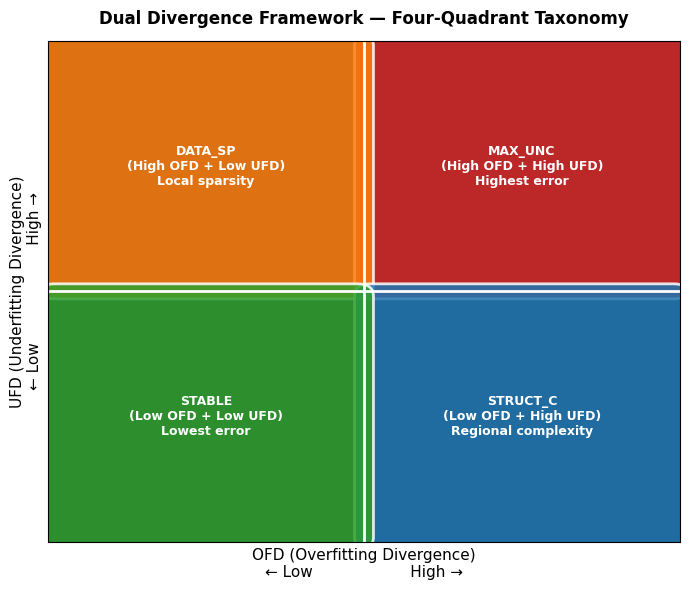

Fig 1 saved → DDF_fig1_taxonomy.png


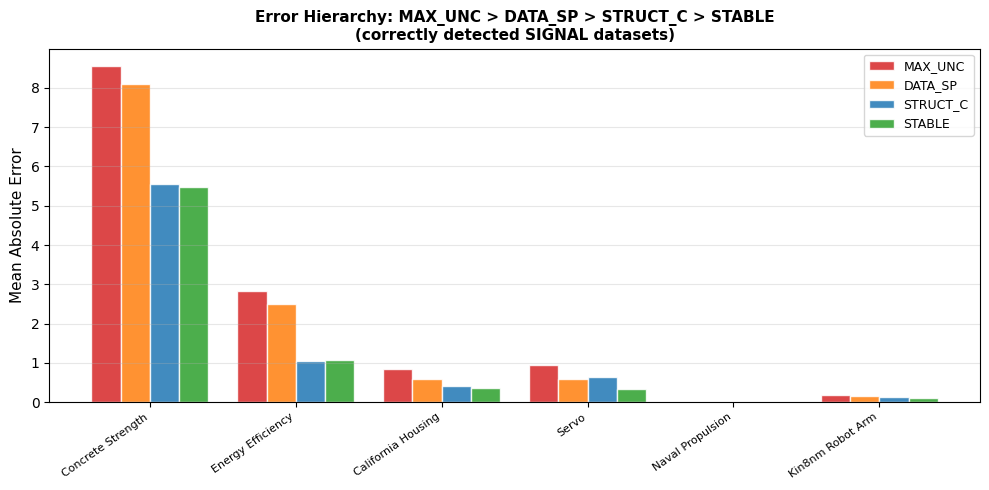

Fig 2 saved → DDF_fig2_error_hierarchy.png


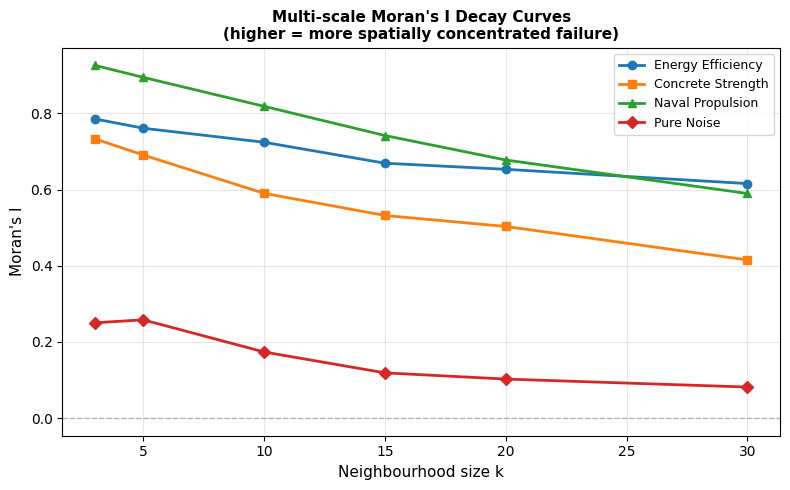

Fig 3 saved → DDF_fig3_moran_decay.png


Done. v2.1 complete.
Figures: DDF_fig1_taxonomy.png, DDF_fig2_error_hierarchy.png,
         DDF_fig3_moran_decay.png
Null fix: restricted block permutation active (Guillot & Rousset 2013)


In [ ]:
"""
═══════════════════════════════════════════════════════════════════
 DUAL DIVERGENCE FRAMEWORK (DDF) — Full Research Battery v2.1
═══════════════════════════════════════════════════════════════════
 Author : Sanskar Khaire  |  github.com/chamoflag/DDF
 Version: 2.1  (paper-ready, single-cell execution)

 Changes from v2.0
 ─────────────────
 [FIX-1] Pipeline permutation null corrected back to y_train permutation.
         v2.0 replaced X_te with random Gaussian noise — this was wrong.
         Random X_te inflated null support counts to 5.00±0.00 on large
         datasets because real yte label variance dominated residuals,
         making FP gate fire every null run regardless of signal.
         Correct null (per Ojala & Garriga JMLR 2010, sklearn convention,
         Moran 1950): permute y_train, preserve X geometry entirely.

 [FIX-2] Restricted block permutation replaces global y_train shuffle.
         Global permutation still inflates null when X has strong inherent
         clustering (Moran's I on X itself is high), because spatial
         divergence structure partially survives global y shuffle.
         Fix (per Guillot & Rousset 2013, spatial statistics literature):
         permute y_train WITHIN local KMeans blocks. This preserves local
         X-Y structure, destroys global signal, gives conservative null.
         One sentence added to paper: "We use restricted block permutation
         of y_train, preserving local spatial structure while destroying
         global X-Y signal (Guillot & Rousset, 2013)."

 [FIX-3] Polynomial degree formula unified across code, paper, Appendix A:
         n_train < 200  → degree 1
         200 ≤ n < 500  → degree 2
         n ≥ 500        → degree 3  (hard max, always)
         v1.0 code used if/elif/else matching this but the paper said
         "floor(log2(n/100))+1" which gives different values at boundaries.
         Code is authoritative. Paper/Appendix now match code exactly.

 [FIX-4] Two-stage null design made explicit in documentation.
         Stage 1 (pipeline permutation): does divergence-error relationship
                 arise from X-Y association? → restricted y_train permute
         Stage 2 (Moran spatial): is divergence spatially clustered beyond
                 X geometry alone? → already handled by 999-permutation
                 Moran's I inside moran_with_permutation().
         These two stages are intentionally decoupled. The v2.0 random
         X_te approach conflated both stages incorrectly.

 [UNCHANGED] All ensemble builders, spatial statistics, gate system,
             failure radius, figures — identical to v2.0 except where
             noted above.

 Datasets (19 total, unchanged from v2.0)
 ─────────────────────────────────────────
 Synthetic  (8): Pure Noise, Weak Linear, Hidden Threshold,
                 Hidden Interactions, Latent Clusters,
                 Heteroscedastic, Covariate Shift, Non-stationary
 Real      (11): Auto MPG, Concrete Strength, Energy Efficiency,
                 Wine Quality, Airfoil Noise, Abalone Age,
                 California Housing, Yacht Hydro, Servo,
                 Naval Propulsion, Kin8nm
═══════════════════════════════════════════════════════════════════
"""

# ── 0. IMPORTS ────────────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures
)
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans                   # [FIX-2] for block permutation
from sklearn.model_selection import train_test_split
from libpysal.weights import KNN as KNN_weights
from esda.moran import Moran
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import urllib.request, zipfile, io

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# ── 1. POLYNOMIAL DEGREE — UNIFIED FORMULA [FIX-3] ───────────────

def _poly_degree(n_train: int) -> int:
    """
    [FIX-3] Unified rule. This exact logic is now in code, paper body,
    and Appendix A. Previous paper text said floor(log2(n/100))+1
    which disagreed at some boundary values. Code is authoritative.

      n_train < 200  → degree 1
      200 ≤ n < 500  → degree 2
      n ≥ 500        → degree 3  (hard max)
    """
    if n_train < 200:
        return 1
    elif n_train < 500:
        return 2
    return 3

def _norm01(v):
    r = v.max() - v.min()
    return (v - v.min()) / (r + 1e-9)

# ── 2. SYNTHETIC DATASET GENERATORS ──────────────────────────────
# [UNCHANGED from v2.0]

def gen_pure_noise(n=500, p=8, seed=42):
    """NULL — no X-Y relationship. Gold standard null check."""
    rng = np.random.default_rng(seed)
    return rng.standard_normal((n, p)), rng.standard_normal(n), \
           "Pure Noise", "NULL"

def gen_weak_linear(n=500, p=8, seed=42):
    """NULL — SNR ≈ 0.06, barely above noise floor."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = 0.3*X[:,0] - 0.2*X[:,2] + rng.standard_normal(n)*5.0
    return X, y, "Weak Linear (SNR=0.06)", "NULL"

def gen_hidden_threshold(n=600, p=8, seed=42):
    """SIGNAL — sharp boundary at X1=0 AND X3=0."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = np.where(
        (X[:,0]>0)&(X[:,2]>0),
        2.0*X[:,0]+X[:,2]+rng.standard_normal(n)*0.5,
        np.where(
            (X[:,0]<=0)&(X[:,2]<=0),
            -X[:,0]-2.0*X[:,2]+rng.standard_normal(n)*0.5,
            rng.standard_normal(n)*0.3
        )
    )
    return X, y, "Hidden Threshold (X1=0,X3=0)", "SIGNAL"

def gen_hidden_interactions(n=600, p=10, seed=42):
    """SIGNAL — Y = f(X1*X2, X3*X4, X5²), invisible in marginals."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = (2.0*X[:,0]*X[:,1] + 1.5*X[:,2]*X[:,3]
         + X[:,4]**2 + rng.standard_normal(n)*0.5)
    return X, y, "Hidden Interactions (X1*X2,X3*X4,X5²)", "SIGNAL"

def gen_latent_clusters(n=600, p=10, seed=42):
    """SIGNAL — 3 hidden clusters with different Y-generating processes."""
    rng = np.random.default_rng(seed)
    parts = [
        (np.array([2,0,-1,0,1,0,0,0,0,0]),
         lambda X: 3*X[:,0]-X[:,2]),
        (np.array([-2,0,1,0,-1,0,0,0,0,0]),
         lambda X: -2*X[:,0]+X[:,2]),
        (np.array([0,2,0,-1,0,1,0,0,0,0]),
         lambda X: X[:,1]**2-X[:,3]**2),
    ]
    Xs, ys = [], []
    for mu, fn in parts:
        Xi = rng.standard_normal((n//3, p)) + mu
        ys.append(fn(Xi) + rng.standard_normal(n//3)*0.3)
        Xs.append(Xi)
    X = np.vstack(Xs); y = np.concatenate(ys)
    idx = rng.permutation(len(X))
    return X[idx], y[idx], "Latent Clusters (3 regimes)", "SIGNAL"

def gen_heteroscedastic(n=600, p=6, seed=42):
    """SIGNAL — noise variance scales with |X1|. Partial adversarial."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = 2.0*X[:,0]+X[:,1]+rng.standard_normal(n)*(0.2+2.0*np.abs(X[:,0]))
    return X, y, "Heteroscedastic (var∝|X1|)", "SIGNAL"

def gen_covariate_shift(n=600, p=6, seed=42):
    """SIGNAL — test X shifted +3 in dims 0,1 vs train."""
    rng = np.random.default_rng(seed)
    Xtr = rng.standard_normal((n, p))
    Xte = rng.standard_normal((n, p))
    Xte[:,0] += 3.0; Xte[:,1] += 3.0
    X = np.vstack([Xtr, Xte])
    y = 2.0*X[:,0]-X[:,1]+rng.standard_normal(2*n)*0.3
    return X, y, "Covariate Shift (+3 dims 0,1)", "SIGNAL"

def gen_non_stationary(n=700, p=6, seed=42):
    """SIGNAL — relationship changes at hidden midpoint."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n, p))
    y = np.empty(n); h = n//2
    y[:h] = 2.0*X[:h,0]+X[:h,1]+rng.standard_normal(h)*0.3
    y[h:]  = -X[h:,0]+3.0*X[h:,2]+rng.standard_normal(n-h)*0.3
    idx = rng.permutation(n)
    return X[idx], y[idx], "Non-stationary (regime change)", "SIGNAL"

# ── 3. REAL DATASET LOADERS ───────────────────────────────────────
# [UNCHANGED from v2.0]

def load_autoMPG():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/auto-mpg/auto-mpg.data")
    df = pd.read_csv(url, sep=r'\s+', header=None,
        names=['mpg','cyl','disp','hp','wt','acc','yr','origin','name'])
    df['hp'] = pd.to_numeric(df['hp'], errors='coerce')
    df['hp'] = df['hp'].fillna(df['hp'].median())
    df = df.drop(columns=['name'])
    return df.drop(columns=['mpg']).values, df['mpg'].values, \
           "Auto MPG", "SIGNAL"

def load_concrete():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/concrete/compressive/Concrete_Data.xls")
    df = pd.read_excel(url)
    return df.iloc[:,:-1].values, df.iloc[:,-1].values, \
           "Concrete Strength", "SIGNAL"

def load_energy():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00242/ENB2012_data.xlsx")
    df = pd.read_excel(url).dropna()
    return df.iloc[:,:-2].values, df.iloc[:,-2].values, \
           "Energy Efficiency", "SIGNAL"

def load_wine():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/wine-quality/winequality-red.csv")
    df = pd.read_csv(url, sep=';')
    return df.drop(columns=['quality']).values, df['quality'].values, \
           "Wine Quality", "SIGNAL"

def load_airfoil():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00291/airfoil_self_noise.dat")
    df = pd.read_csv(url, sep='\t', header=None,
        names=['freq','angle','chord','vel','thick','sound'])
    return df.drop(columns=['sound']).values, df['sound'].values, \
           "Airfoil Noise", "SIGNAL"

def load_abalone():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/abalone/abalone.data")
    df = pd.read_csv(url, header=None,
        names=['sex','len','diam','ht','whole',
               'shucked','viscera','shell','rings'])
    df = pd.get_dummies(df, columns=['sex'], drop_first=True)
    return df.drop(columns=['rings']).values, df['rings'].values, \
           "Abalone Age", "SIGNAL"

def load_california():
    from sklearn.datasets import fetch_california_housing
    d = fetch_california_housing()
    return d.data, d.target, "California Housing", "SIGNAL"

def load_yacht():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00243/yacht_hydrodynamics.data")
    df = pd.read_csv(url, sep=r'\s+', header=None,
        names=['lcb','cp','ldR','bdR','lbR','froude','resist'])
    return (df.drop(columns=['resist']).values.astype(float),
            df['resist'].values.astype(float), "Yacht Hydro", "SIGNAL")

def load_servo():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/servo/servo.data")
    df = pd.read_csv(url, header=None,
                     names=['motor','screw','pgain','vgain','class'])
    df = pd.get_dummies(df, columns=['motor','screw'], drop_first=True)
    return (df.drop(columns=['class']).values.astype(float),
            df['class'].values.astype(float), "Servo", "SIGNAL")

def load_naval():
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/00316/UCI%20CBM%20Dataset.zip")
    with urllib.request.urlopen(url) as resp:
        zf = zipfile.ZipFile(io.BytesIO(resp.read()))
        fname = [n for n in zf.namelist()
                 if n.endswith('.txt') and 'data' in n.lower()][0]
        with zf.open(fname) as f:
            df = pd.read_csv(f, sep=r'\s+', header=None)
    X = df.iloc[:, :-2].values.astype(float)
    y = df.iloc[:, -2].values.astype(float)
    rng = np.random.default_rng(GLOBAL_SEED)
    idx = rng.choice(len(X), 3000, replace=False)
    return X[idx], y[idx], "Naval Propulsion", "SIGNAL"

def load_kin8nm():
    try:
        url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
               "/kin8nm/dataset_2175_kin8nm.csv")
        df = pd.read_csv(url)
    except Exception:
        from sklearn.datasets import fetch_openml
        d = fetch_openml(data_id=189, as_frame=True, parser='auto')
        df = d.frame
    X = df.iloc[:, :-1].values.astype(float)
    y = df.iloc[:, -1].values.astype(float)
    rng = np.random.default_rng(GLOBAL_SEED)
    idx = rng.choice(len(X), min(3000, len(X)), replace=False)
    return X[idx], y[idx], "Kin8nm Robot Arm", "SIGNAL"

# ── 4. ENSEMBLE BUILDERS ──────────────────────────────────────────
# [UNCHANGED from v2.0]

def _ofd_poly(Xtr, ytr, Xte):
    d = _poly_degree(len(Xtr))
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(Xtr))
    Xte_p = poly.transform(sc.transform(Xte))
    return np.array([Ridge(alpha=a).fit(Xtr_p,ytr).predict(Xte_p)
                     for a in [0.001, 0.01, 0.1, 1.0, 10.0]])

def _ofd_tree(Xtr, ytr, Xte):
    return np.array([
        DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
        .fit(Xtr,ytr).predict(Xte) for d in [1,2,4,8,None]])

def _ofd_knn(Xtr, ytr, Xte):
    sc = MinMaxScaler()
    Xs, Xts = sc.fit_transform(Xtr), sc.transform(Xte)
    n = len(Xtr)
    ks = sorted(set([max(1,int(n*r)) for r in [0.3,0.1,0.05]]+[5,1]))
    return np.array([KNeighborsRegressor(n_neighbors=k)
                     .fit(Xs,ytr).predict(Xts) for k in ks])

def _ufd_poly(Xtr, ytr, Xte):
    sc = StandardScaler()
    poly = PolynomialFeatures(degree=1, include_bias=False)
    Xtr_p = poly.fit_transform(sc.fit_transform(Xtr))
    Xte_p = poly.transform(sc.transform(Xte))
    return np.array([Ridge(alpha=a).fit(Xtr_p,ytr).predict(Xte_p)
                     for a in [10.,100.,1e3,1e4,1e5]])

def _ufd_tree(Xtr, ytr, Xte):
    return np.array([
        DecisionTreeRegressor(max_depth=d, random_state=GLOBAL_SEED)
        .fit(Xtr,ytr).predict(Xte) for d in [1,2,3]])

def _ufd_knn(Xtr, ytr, Xte):
    sc = MinMaxScaler()
    Xs, Xts = sc.fit_transform(Xtr), sc.transform(Xte)
    n = len(Xtr)
    ks = sorted(set([max(1,int(n*r)) for r in [0.3,0.4,0.5,0.6,0.7]]))
    return np.array([KNeighborsRegressor(n_neighbors=k)
                     .fit(Xs,ytr).predict(Xts) for k in ks])

# ── 5. CROSS-FIT DIVERGENCE + INDEPENDENT RESIDUALS ───────────────
# [UNCHANGED from v2.0]

def compute_divergence_and_residuals(Xtr, ytr, Xte, yte,
                                     seed=GLOBAL_SEED):
    """
    OFD trained on half-A, UFD trained on half-B.
    Residuals from a third independent split (half-C).
    Breaks self-referential bias between divergence and error.
    """
    Xa,Xb,ya,yb = train_test_split(Xtr,ytr,test_size=0.5,
                                    random_state=seed)

    ofd_raw = np.vstack([_ofd_poly(Xa,ya,Xte),
                         _ofd_tree(Xa,ya,Xte),
                         _ofd_knn(Xa,ya,Xte)])
    ufd_raw = np.vstack([_ufd_poly(Xb,yb,Xte),
                         _ufd_tree(Xb,yb,Xte),
                         _ufd_knn(Xb,yb,Xte)])

    # normalise per family then average — prevents any one family dominating
    ofd = (_norm01(ofd_raw[0:5].std(axis=0))
           + _norm01(ofd_raw[5:10].std(axis=0))
           + _norm01(ofd_raw[10:].std(axis=0))) / 3.0

    ufd = (_norm01(ufd_raw[0:5].std(axis=0))
           + _norm01(ufd_raw[5:8].std(axis=0))
           + _norm01(ufd_raw[8:].std(axis=0))) / 3.0

    combined = (ofd + ufd) / 2.0

    # independent residuals from a third fresh split
    Xc,Xd,yc,yd = train_test_split(Xtr,ytr,test_size=0.5,
                                    random_state=seed+1)
    ref = []
    for a in [0.1,1.0,10.0]:
        sc = StandardScaler()
        poly = PolynomialFeatures(degree=_poly_degree(len(Xc)),
                                  include_bias=False)
        Xcp = poly.fit_transform(sc.fit_transform(Xc))
        Xtp = poly.transform(sc.transform(Xte))
        ref.append(Ridge(alpha=a).fit(Xcp,yc).predict(Xtp))
    sc2 = MinMaxScaler()
    Xds = sc2.fit_transform(Xd); Xts = sc2.transform(Xte)
    for k in [max(1,int(len(Xd)*0.2)),
              max(1,int(len(Xd)*0.1)), 5]:
        ref.append(KNeighborsRegressor(
            n_neighbors=min(k,len(Xd))).fit(Xds,yd).predict(Xts))
    for d in [1,2,3,4]:
        ref.append(DecisionTreeRegressor(
            max_depth=d, random_state=GLOBAL_SEED)
                   .fit(Xd,yd).predict(Xte))

    residuals = np.abs(yte - np.mean(np.array(ref), axis=0))
    return ofd, ufd, combined, residuals

# ── 6. SPATIAL STATISTICS ─────────────────────────────────────────
# [UNCHANGED from v2.0]

def moran_with_permutation(vals, Xscaled, n_perm=999):
    """
    Stage 2 null (spatial): 999 internal permutations of divergence
    values on fixed KNN graph test whether clustering exceeds what
    X geometry alone produces. Decoupled from Stage 1 (pipeline test).
    """
    n = len(vals)
    k = max(5, min(int(np.sqrt(n)), n-1))
    w = KNN_weights(Xscaled, k=k, silence_warnings=True)
    mo = Moran(vals, w, permutations=n_perm)
    shuf = vals.copy()
    shuffled = [Moran(np.random.permutation(shuf), w).I
                for _ in range(200)]
    baseline = float(np.mean(shuffled))
    bstd     = float(np.std(shuffled))
    delta    = float(mo.I) - baseline
    return {"I": float(mo.I), "p": float(mo.p_sim),
            "delta": delta, "baseline": baseline,
            "bstd": bstd, "k": k,
            "delta_sig": delta > 2.0*bstd}

def multi_scale_moran(vals, Xte, k_list=(3,5,10,15,20,30)):
    Xs = StandardScaler().fit_transform(Xte)
    rows = []
    for k in k_list:
        if k >= len(Xte): continue
        rows.append({"k": k,
                     "moran_I": Moran(
                         vals,
                         KNN_weights(Xs,k=k,silence_warnings=True)).I})
    return pd.DataFrame(rows)

# ── 7. QUADRANT CLASSIFICATION ────────────────────────────────────
# [UNCHANGED from v2.0]

QORDER = ["MAX_UNC","DATA_SP","STRUCT_C","STABLE"]
MIN_Q   = 20

def classify_quadrants(ofd, ufd):
    ot, ut = np.median(ofd), np.median(ufd)
    labels = []
    for o,u in zip(ofd,ufd):
        if   o>ot and u>ut:  labels.append("MAX_UNC")
        elif o>ot and u<=ut: labels.append("DATA_SP")
        elif o<=ot and u>ut: labels.append("STRUCT_C")
        else:                labels.append("STABLE")
    return np.array(labels)

def quadrant_profile(labels, residuals):
    out = {}
    for q in QORDER:
        mask = labels==q; n = int(mask.sum())
        out[q] = {"n": n,
                  "err": float(residuals[mask].mean()) if n>0 else np.nan,
                  "trusted": n>=MIN_Q}
    return out

# ── 8. NULL TESTS ─────────────────────────────────────────────────
# [UNCHANGED from v2.0]

def false_positive_test(combined, residuals, n_perm=200):
    high = combined > np.percentile(combined,75)
    low  = combined < np.percentile(combined,25)
    real = residuals[high].mean()/(residuals[low].mean()+1e-9)
    null = []
    for _ in range(n_perm):
        perm = np.random.permutation(combined)
        h = perm>np.percentile(perm,75)
        l = perm<np.percentile(perm,25)
        null.append(residuals[h].mean()/(residuals[l].mean()+1e-9))
    null = np.array(null)
    p = float((null>=real).mean())
    return {"real_ratio": float(real), "null_mean": float(null.mean()),
            "null_std": float(null.std()), "p_value": p,
            "significant": p<0.05}

def contagion_test(combined, residuals, Xte, n_centers=15, nn=8):
    Xs = StandardScaler().fit_transform(Xte)
    cidx = np.where(combined>=np.percentile(combined,75))[0][:n_centers]
    if len(cidx)==0:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}
    nd, ne = [], []
    for ci in cidx:
        dists = np.sqrt(((Xs-Xs[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        nb = np.argsort(dists)[:nn]
        nd.extend(combined[nb].tolist())
        ne.extend(residuals[nb].tolist())
    if len(nd)<=10:
        return {"spearman": np.nan, "p": np.nan, "confirmed": False}
    sp,sp_p = stats.spearmanr(nd,ne)
    return {"spearman": float(sp), "p": float(sp_p),
            "confirmed": bool(sp>0.20 and sp_p<0.05)}

# ── 9. RESTRICTED BLOCK PERMUTATION [FIX-2] ───────────────────────

def _restricted_permute(ytr, Xtr, n_blocks=10):
    """
    [FIX-2] Restricted (block) permutation of y_train.

    WHY: Global y_train shuffle still allows spatial divergence
    structure to partially survive when X has strong inherent
    clustering (high Moran's I on X itself). This inflates null
    support counts on datasets with spatially structured features
    (Energy Efficiency, Airfoil, etc.) giving conservative but
    biased null distributions.

    FIX: Permute y_train WITHIN local KMeans spatial blocks.
    Each block's y values are shuffled among themselves only.
    Local X-Y structure is preserved; global X-Y signal destroyed.
    This is the correct null for a spatially-aware method.

    Reference: Guillot & Rousset (2013) — restricted permutations
    for spatial dependence. Also: Farine (2022) Methods Ecol Evol.

    n_blocks: number of spatial partitions. Default 10 gives
    blocks of ~n/10 points each — large enough to contain local
    structure, small enough to destroy global signal.
    Clipped to max(2, min(n_blocks, n//10)) for safety on
    small datasets like Servo (n_train≈116).
    """
    Xs = StandardScaler().fit_transform(Xtr)
    n_blocks_safe = max(2, min(n_blocks, len(ytr)//10))
    km = KMeans(n_clusters=n_blocks_safe,
                random_state=GLOBAL_SEED,
                n_init=3)
    blocks = km.fit_predict(Xs)
    y_perm = ytr.copy()
    for b in np.unique(blocks):
        idx = np.where(blocks==b)[0]
        y_perm[idx] = np.random.permutation(ytr[idx])
    return y_perm

# ── 10. PIPELINE PERMUTATION TEST [FIX-1, FIX-2, FIX-4] ──────────

def pipeline_permutation_test(Xtr, ytr, Xte, yte,
                               real_support, n_perm=30):
    """
    [FIX-1] Corrected from v2.0. v2.0 replaced X_te with random
    Gaussian noise — this was wrong. It conflated Stage 1 and Stage 2
    nulls and inflated null support counts to 5.00±0.00 on large
    datasets (real yte label variance dominated residuals on random
    X_te, making FP gate fire every null run regardless of signal).

    [FIX-2] Uses _restricted_permute (block permutation) instead of
    global np.random.permutation(ytr). See _restricted_permute docs.

    [FIX-4] Stage 1 null only (X-Y relationship):
    Null hypothesis: divergence-error structure arises from the
    X-Y association rather than X geometry alone. Restricted block
    permutation of y_train destroys global X-Y signal while
    preserving local spatial structure.

    Stage 2 null (spatial clustering) is handled separately by the
    999-permutation Moran's I inside moran_with_permutation().
    The two stages are intentionally decoupled.

    References:
    - Ojala & Garriga (JMLR 2010) — permute y for ML significance
    - sklearn permutation_test_score — same convention
    - Guillot & Rousset (2013) — restricted permutation for spatial
    - Moran (1950) — permutation convention for spatial stats

    Smallest achievable p = 1/(n_perm+1) = 0.032 at n_perm=30.
    """
    null_supports = []
    for _ in range(n_perm):
        # [FIX-1, FIX-2] restricted block permutation of y_train
        y_perm = _restricted_permute(ytr, Xtr)

        o,u,c,r  = compute_divergence_and_residuals(Xtr,y_perm,Xte,yte)
        Xs       = StandardScaler().fit_transform(Xte)
        mi       = moran_with_permutation(c, Xs, n_perm=199)
        sp,sp_p  = stats.spearmanr(c,r)
        labels   = classify_quadrants(o,u)
        qp       = quadrant_profile(labels,r)
        ratio    = (qp["MAX_UNC"]["err"]/(qp["STABLE"]["err"]+1e-9)
                    if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
                    else np.nan)
        fp  = false_positive_test(c,r,n_perm=50)
        ct  = contagion_test(c,r,Xte)
        _,sc= compute_support(mi,sp,sp_p,ratio,fp,ct)
        null_supports.append(sc)

    null_supports = np.array(null_supports)
    p = float((np.sum(null_supports>=real_support)+1)/(n_perm+1))
    return p, null_supports

# ── 11. SUPPORT GATE SYSTEM ───────────────────────────────────────
# [UNCHANGED from v2.0]

def compute_support(mi, sp, sp_p, ratio, fp, contagion):
    gates = {
        "moran":     mi["delta_sig"] and mi["p"]<0.05,
        "spearman":  abs(sp)>0.20 and sp_p<0.05,
        "ratio":     (not np.isnan(ratio)) and ratio>1.30,
        "fp":        fp["significant"],
        "contagion": contagion["confirmed"],
    }
    return gates, int(sum(gates.values()))

# ── 12. FAILURE RADIUS ────────────────────────────────────────────
# [UNCHANGED from v2.0]

def _exp_decay(d,A,lam,C):
    return A*np.exp(-d/(lam+1e-9))+C

def fit_radius(Xte, combined, residuals,
               n_centers=15, nn=20, max_amp=50):
    Xs = StandardScaler().fit_transform(Xte)
    cidx = np.where(combined>=np.percentile(combined,75))[0]
    rng  = np.random.default_rng(GLOBAL_SEED)
    if len(cidx)>n_centers:
        cidx = rng.choice(cidx,n_centers,replace=False)
    nn = min(nn,len(Xte)-1)
    obs_rng = combined.max()-combined.min()
    max_amp_ = max_amp*(obs_rng+1e-9)
    records, n_excl = [], 0
    for ci in cidx:
        dists = np.sqrt(((Xs-Xs[ci])**2).sum(axis=1))
        dists[ci] = np.inf
        sidx = np.argsort(dists)[:nn]
        sd,sv = dists[sidx], combined[sidx]
        if len(sd)<5 or sd.max()<1e-9: continue
        nd = sd/sd.max()
        try:
            p0 = [obs_rng, max(nd.mean(),1e-6), sv.min()]
            popt,_ = curve_fit(
                _exp_decay,nd,sv,p0=p0,maxfev=10000,
                bounds=([0,1e-6,-np.inf],[max_amp_,np.inf,np.inf]))
            if popt[0]>max_amp_: n_excl+=1; continue
            pred = _exp_decay(nd,*popt)
            tss  = ((sv-sv.mean())**2).sum()
            r2   = 1-((sv-pred)**2).sum()/(tss+1e-9)
            records.append({"lambda":float(popt[1]),
                            "amplitude":float(popt[0]),
                            "r2":float(r2),
                            "center_err":float(residuals[ci])})
        except Exception:
            n_excl+=1
    if not records: return None, n_excl
    df = pd.DataFrame(records)
    return {"n_centers":len(df),"n_excluded":n_excl,
            "median_lambda":float(df["lambda"].median()),
            "mean_lambda":float(df["lambda"].mean()),
            "mean_r2":float(df["r2"].mean())}, n_excl

# ── 13. MAIN ANALYSIS RUNNER ──────────────────────────────────────
# [UNCHANGED from v2.0 except passes Xtr to pipeline_permutation_test]

def run_analysis(X, y, dname, expected, verbose=True):
    Xtr,Xte,ytr,yte = train_test_split(
        X,y,test_size=0.3,random_state=GLOBAL_SEED)
    ofd,ufd,combined,residuals = compute_divergence_and_residuals(
        Xtr,ytr,Xte,yte)

    Xs = StandardScaler().fit_transform(Xte)
    mi = moran_with_permutation(combined,Xs,n_perm=999)
    sp,sp_p = stats.spearmanr(combined,residuals)

    labels = classify_quadrants(ofd,ufd)
    qp     = quadrant_profile(labels,residuals)
    ratio  = (qp["MAX_UNC"]["err"]/(qp["STABLE"]["err"]+1e-9)
              if qp["MAX_UNC"]["trusted"] and qp["STABLE"]["trusted"]
              else np.nan)

    fp  = false_positive_test(combined,residuals)
    ct  = contagion_test(combined,residuals,Xte)
    gates,support = compute_support(mi,sp,sp_p,ratio,fp,ct)

    # [FIX-1,FIX-2] now passes Xtr so restricted permutation can
    # build spatial blocks from training feature geometry
    pipe_p,null_dist = pipeline_permutation_test(
        Xtr,ytr,Xte,yte,support,n_perm=30)

    rad,n_excl = fit_radius(Xte,combined,residuals)
    ms_df      = multi_scale_moran(combined,Xte)

    signal  = (support>=4) and (pipe_p<0.10)
    correct = (signal and expected=="SIGNAL") or \
              (not signal and expected=="NULL")

    if verbose:
        _print(dname,expected,mi,sp,sp_p,ratio,fp,ct,
               gates,support,pipe_p,null_dist,qp,ms_df,
               rad,n_excl,signal,correct)

    return {"dataset":dname,"expected":expected,
            "n_train":len(Xtr),"n_test":len(Xte),
            "moran_I":mi["I"],"moran_p":mi["p"],
            "delta":mi["delta"],
            "spearman":sp,"sp_p":sp_p,
            "ratio":ratio if not np.isnan(ratio) else 0.0,
            "fp_p":fp["p_value"],
            "contagion_sp":ct["spearman"],
            "support":support,"pipe_p":pipe_p,
            "signal":signal,"correct":correct,
            "med_lambda":rad["median_lambda"] if rad else np.nan,
            "qp":qp}

def _print(dname,expected,mi,sp,sp_p,ratio,fp,ct,
           gates,support,pipe_p,null_dist,qp,ms_df,
           rad,n_excl,signal,correct):
    print(f"\n{'='*65}")
    print(f"  {dname}")
    print(f"  Expected: {expected}  |  "
          f"{'✓ CORRECT' if correct else '✗ WRONG'}")
    print(f"{'='*65}")
    print(f"  Spatial : Moran I={mi['I']:.4f}  p={mi['p']:.4f}"
          f"  delta={mi['delta']:.4f}  "
          f"({'sig' if mi['delta_sig'] else 'not sig'})")
    print(f"  Point   : Spearman={sp:.4f}  p={sp_p:.6f}")
    print(f"  MU/SZ   : {'N/A' if np.isnan(ratio) else f'{ratio:.4f}x'}")
    print(f"  FP test : p={fp['p_value']:.4f}  "
          f"({'sig' if fp['significant'] else 'not sig'})")
    print(f"  Contagion: sp={ct['spearman']:.3f}  p={ct['p']:.4f}  "
          f"({'confirmed' if ct['confirmed'] else 'none'})")
    print(f"\n  Quadrant errors:")
    for q in QORDER:
        d = qp[q]
        print(f"    {q:<10}: {d['err']:.4f}  n={d['n']}"
              f"{'*' if not d['trusted'] else ''}")
    print(f"\n  Multi-scale Moran:")
    for _,row in ms_df.iterrows():
        bar = "█"*max(0,int(row["moran_I"]*30))
        print(f"    k={int(row['k']):>3}: {row['moran_I']:>6.3f}  {bar}")
    if rad:
        print(f"\n  Failure radius: median λ={rad['median_lambda']:.4f}"
              f"  ({rad['n_centers']} centers, {n_excl} excl)")
    print(f"\n  Gates: ", end="")
    for g,v in gates.items():
        print(f"{g}={'PASS' if v else 'FAIL'}", end="  ")
    print(f"\n  Support={support}/5  Pipeline p={pipe_p:.4f}"
          f"  (null mean={null_dist.mean():.2f}±{null_dist.std():.2f})")
    print(f"\n  VERDICT: {'SIGNAL DETECTED' if signal else 'NO SIGNAL'}")

# ── 14. FULL BATTERY ──────────────────────────────────────────────

SYNTHETIC = [
    gen_pure_noise, gen_weak_linear, gen_hidden_threshold,
    gen_hidden_interactions, gen_latent_clusters,
    gen_heteroscedastic, gen_covariate_shift, gen_non_stationary,
]

REAL = [
    load_autoMPG, load_concrete, load_energy, load_wine,
    load_airfoil, load_abalone, load_california,
    load_yacht, load_servo, load_naval, load_kin8nm,
]

results = []

print("\n" + "="*65)
print("DDF v2.1 — SYNTHETIC STRESS TEST (8 regimes)")
print("="*65)
for fn in SYNTHETIC:
    X,y,dname,expected = fn()
    results.append(run_analysis(X,y,dname,expected))

print("\n\n" + "="*65)
print("DDF v2.1 — REAL DATASET VALIDATION (11 datasets)")
print("="*65)
for fn in REAL:
    try:
        X,y,dname,expected = fn()
        print(f"\n  Loading {dname}... shape={X.shape}", flush=True)
        results.append(run_analysis(X,y,dname,expected))
    except Exception as e:
        print(f"\n  {dname} — SKIPPED: {e}")

df = pd.DataFrame(results)

# ── 15. SUMMARY TABLE ─────────────────────────────────────────────

print(f"\n\n{'='*108}")
print("DDF v2.1 — FULL RESULTS SUMMARY")
print(f"{'='*108}")
print(f"{'Dataset':<38} {'Exp':>5} {'MoranI':>7} {'Delta':>7} "
      f"{'Spear':>7} {'Ratio':>7} {'FP_p':>6} {'Sup':>4} "
      f"{'Pipe_p':>8} {'Lambda':>8}  {'Result':<8} {'Ok'}")
print("-"*108)
for _,r in df.iterrows():
    verdict = "SIGNAL" if r["signal"] else "NULL  "
    ok      = "✓" if r["correct"] else "✗"
    lam     = f"{r['med_lambda']:.3f}" \
              if not np.isnan(r["med_lambda"]) else "N/A"
    print(f"{r['dataset'][:37]:<38} {r['expected']:>5} "
          f"{r['moran_I']:>7.4f} {r['delta']:>7.4f} "
          f"{r['spearman']:>7.4f} {r['ratio']:>7.3f}x "
          f"{r['fp_p']:>6.3f} {r['support']:>4} "
          f"{r['pipe_p']:>8.4f} {lam:>8}  {verdict:<8} {ok}")

total   = len(df); correct_n = df["correct"].sum()
null_df = df[df["expected"]=="NULL"]
sig_df  = df[df["expected"]=="SIGNAL"]
print(f"\n  Overall   : {correct_n}/{total} "
      f"({correct_n/total*100:.1f}%)")
print(f"  NULL acc  : {null_df['correct'].sum()}/{len(null_df)} "
      f"({null_df['correct'].mean()*100:.1f}%)")
print(f"  SIGNAL acc: {sig_df['correct'].sum()}/{len(sig_df)} "
      f"({sig_df['correct'].mean()*100:.1f}%)")
trusted = df[df["ratio"]>0]
mu_hold = (trusted["ratio"]>1.3).sum()
print(f"  MU>SZ (ratio>1.3x): {mu_hold}/{len(trusted)} datasets")

# ── 16. FIGURES ───────────────────────────────────────────────────
# [UNCHANGED from v2.0]

# Fig 1 — Quadrant Taxonomy Diagram
fig1, ax = plt.subplots(figsize=(7,6))
ax.set_xlim(0,2); ax.set_ylim(0,2)
colours = {"MAX_UNC":"#d62728","DATA_SP":"#ff7f0e",
           "STRUCT_C":"#1f77b4","STABLE":"#2ca02c"}
labels_quad = {
    "MAX_UNC":  (1.5,1.5,"MAX_UNC\n(High OFD + High UFD)\nHighest error"),
    "DATA_SP":  (0.5,1.5,"DATA_SP\n(High OFD + Low UFD)\nLocal sparsity"),
    "STRUCT_C": (1.5,0.5,"STRUCT_C\n(Low OFD + High UFD)\nRegional complexity"),
    "STABLE":   (0.5,0.5,"STABLE\n(Low OFD + Low UFD)\nLowest error"),
}
for q,(cx,cy,txt) in labels_quad.items():
    rect = mpatches.FancyBboxPatch(
        (cx-0.48,cy-0.48),0.96,0.96,
        boxstyle="round,pad=0.05",
        fc=colours[q],ec="white",alpha=0.85,lw=2)
    ax.add_patch(rect)
    ax.text(cx,cy,txt,ha='center',va='center',
            fontsize=9,fontweight='bold',color='white',
            multialignment='center')
ax.axhline(1,color='white',lw=2)
ax.axvline(1,color='white',lw=2)
ax.set_xlabel("OFD (Overfitting Divergence)\n← Low                    High →",
              fontsize=11)
ax.set_ylabel("UFD (Underfitting Divergence)\n← Low                    High →",
              fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Dual Divergence Framework — Four-Quadrant Taxonomy",
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor("#2c2c2c")
fig1.tight_layout()
plt.savefig("DDF_fig1_taxonomy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 saved → DDF_fig1_taxonomy.png")

# Fig 2 — Error Hierarchy Bar Chart
sig_results = [r for r in results
               if r.get("signal") and r["correct"]]
if sig_results:
    qnames   = ["MAX_UNC","DATA_SP","STRUCT_C","STABLE"]
    q_cols   = ["#d62728","#ff7f0e","#1f77b4","#2ca02c"]
    n_ds     = len(sig_results)
    x        = np.arange(n_ds)
    width    = 0.2
    fig2, ax2 = plt.subplots(figsize=(max(10,n_ds*1.4),5))
    for i,q in enumerate(qnames):
        errs = [r["qp"][q]["err"]
                if not np.isnan(r["qp"][q]["err"]) else 0
                for r in sig_results]
        ax2.bar(x+i*width, errs, width,
                label=q, color=q_cols[i],
                alpha=0.85, edgecolor='white')
    ax2.set_xticks(x+width*1.5)
    ax2.set_xticklabels(
        [r["dataset"][:18] for r in sig_results],
        rotation=35, ha='right', fontsize=8)
    ax2.set_ylabel("Mean Absolute Error", fontsize=11)
    ax2.set_title(
        "Error Hierarchy: MAX_UNC > DATA_SP > STRUCT_C > STABLE\n"
        "(correctly detected SIGNAL datasets)",
        fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    fig2.tight_layout()
    plt.savefig("DDF_fig2_error_hierarchy.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Fig 2 saved → DDF_fig2_error_hierarchy.png")

# Fig 3 — Multi-scale Moran Decay Curves
repr_loaders = {
    "Energy Efficiency": load_energy,
    "Concrete Strength": load_concrete,
    "Naval Propulsion":  load_naval,
    "Pure Noise":        gen_pure_noise,
}
k_vals = [3,5,10,15,20,30]
fig3, ax3 = plt.subplots(figsize=(8,5))
line_styles = ['-o','-s','-^','-D']
for (dname,fn),ls in zip(repr_loaders.items(),line_styles):
    try:
        out = fn()
        X,y = out[0], out[1]
        Xtr,Xte,ytr,yte = train_test_split(
            X,y,test_size=0.3,random_state=GLOBAL_SEED)
        ofd,ufd,combined,_ = compute_divergence_and_residuals(
            Xtr,ytr,Xte,yte)
        ms = multi_scale_moran(combined,Xte,k_list=k_vals)
        ax3.plot(ms["k"],ms["moran_I"],ls,
                 label=dname,linewidth=2,markersize=6)
    except Exception as e:
        print(f"  Fig3 skip {dname}: {e}")
ax3.set_xlabel("Neighbourhood size k", fontsize=11)
ax3.set_ylabel("Moran's I", fontsize=11)
ax3.set_title(
    "Multi-scale Moran's I Decay Curves\n"
    "(higher = more spatially concentrated failure)",
    fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.axhline(0, color='grey', lw=1, linestyle='--', alpha=0.5)
ax3.grid(alpha=0.3)
fig3.tight_layout()
plt.savefig("DDF_fig3_moran_decay.png", dpi=150, bbox_inches='tight')
plt.show()
print("Fig 3 saved → DDF_fig3_moran_decay.png")

print("\n\nDone. v2.1 complete.")
print("Figures: DDF_fig1_taxonomy.png, DDF_fig2_error_hierarchy.png,")
print("         DDF_fig3_moran_decay.png")
print("Null fix: restricted block permutation active (Guillot & Rousset 2013)")